## 00. Imports

In [1]:
import numpy as np

In [119]:
#import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from tensorflow.keras.datasets import mnist
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
import concurrent.futures
import json
import os

from graph_based_codebase import extract_graph, merge_similar_edges


#import bezier
from scipy import ndimage as ndi

## 01. Download the datasets

In [120]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## 02. Preprocess imgaes - extract edges and skeletonize

## 02.A

In [121]:
def preprocess_image(img, threshold=30):
    # Normalize and convert to uint8
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Apply a binary threshold to clean noise
    _, img = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
    return img

def extract_edges(img):
    # Use Canny edge detector
    edges = cv2.Canny(img, threshold1=100, threshold2=125)
    return edges

def image_to_graph(edge_img, connectivity=8):
    """
    Convert edge pixels to a graph.
    Each white pixel becomes a node.
    Nodes are connected if they're adjacent (based on connectivity).
    """
    G = nx.Graph()
    h, w = edge_img.shape

    for y in range(h):
        for x in range(w):
            if edge_img[y, x] == 255:
                G.add_node((x, -y))  # Pixel coordinates as node ID

                # Define neighborhood offsets
                neighbors = [(-1, -1), (-1, 0), (-1, 1),
                             ( 0, -1),          ( 0, 1),
                             ( 1, -1), ( 1, 0), ( 1, 1)] if connectivity == 8 else [(-1, 0), (0, -1), (0, 1), (1, 0)]

                for dy, dx in neighbors:
                    ny, nx_ = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx_ < w and edge_img[ny, nx_] == 255:
                        G.add_edge((x, -y), (nx_, -ny))
    return G

def plot_graph(G, ax):
    """Plot the graph on the given axis."""
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)

## 02.B Extract the graphs

In [122]:
def mnist_to_graph(img):
    # Load image

    # Preprocess
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    #img = cv2.medianBlur(img,3)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY) # I tried with 0, 5, 20, 30

    # print unique values in img
    #print(np.unique(binary))

    # Edge detection
    edges = cv2.Canny(binary, 100, 200)

    # Skeletonization: input must be boolean
    skeleton = skeletonize(edges > 0).astype(np.uint8)

    # Graph extraction
    graph = extract_graph(skeleton)

    # Optional: show intermediate steps
    # fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    # axs[0].imshow(img, cmap='gray'); axs[0].set_title("Original")
    # axs[1].imshow(edges, cmap='gray'); axs[1].set_title("Edges")
    # axs[2].imshow(skeleton, cmap='gray'); axs[2].set_title("Skeleton")
    # plt.tight_layout(); plt.show()

    return graph

Graph has 82 nodes and 82 edges.


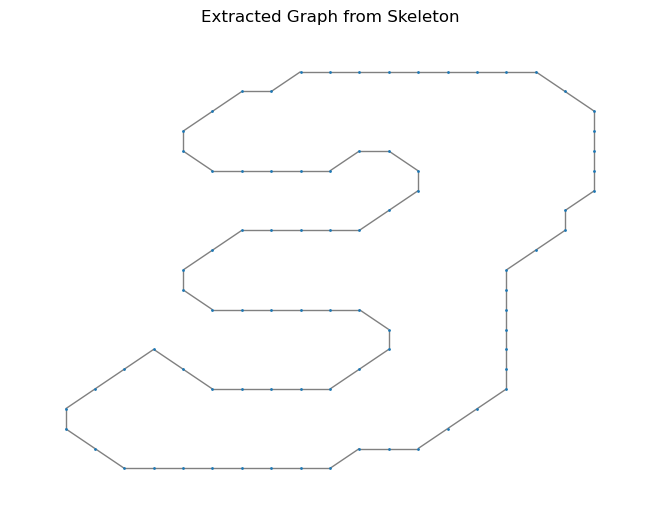

In [123]:
img = x_train[y_train == 3][0]  # Pick the first digit of class '1'
G = mnist_to_graph(img)
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Optional: draw graph with positions
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, node_size=1, edge_color='gray')
plt.title("Extracted Graph from Skeleton")
plt.show()

### Show for 10 examples of each digit

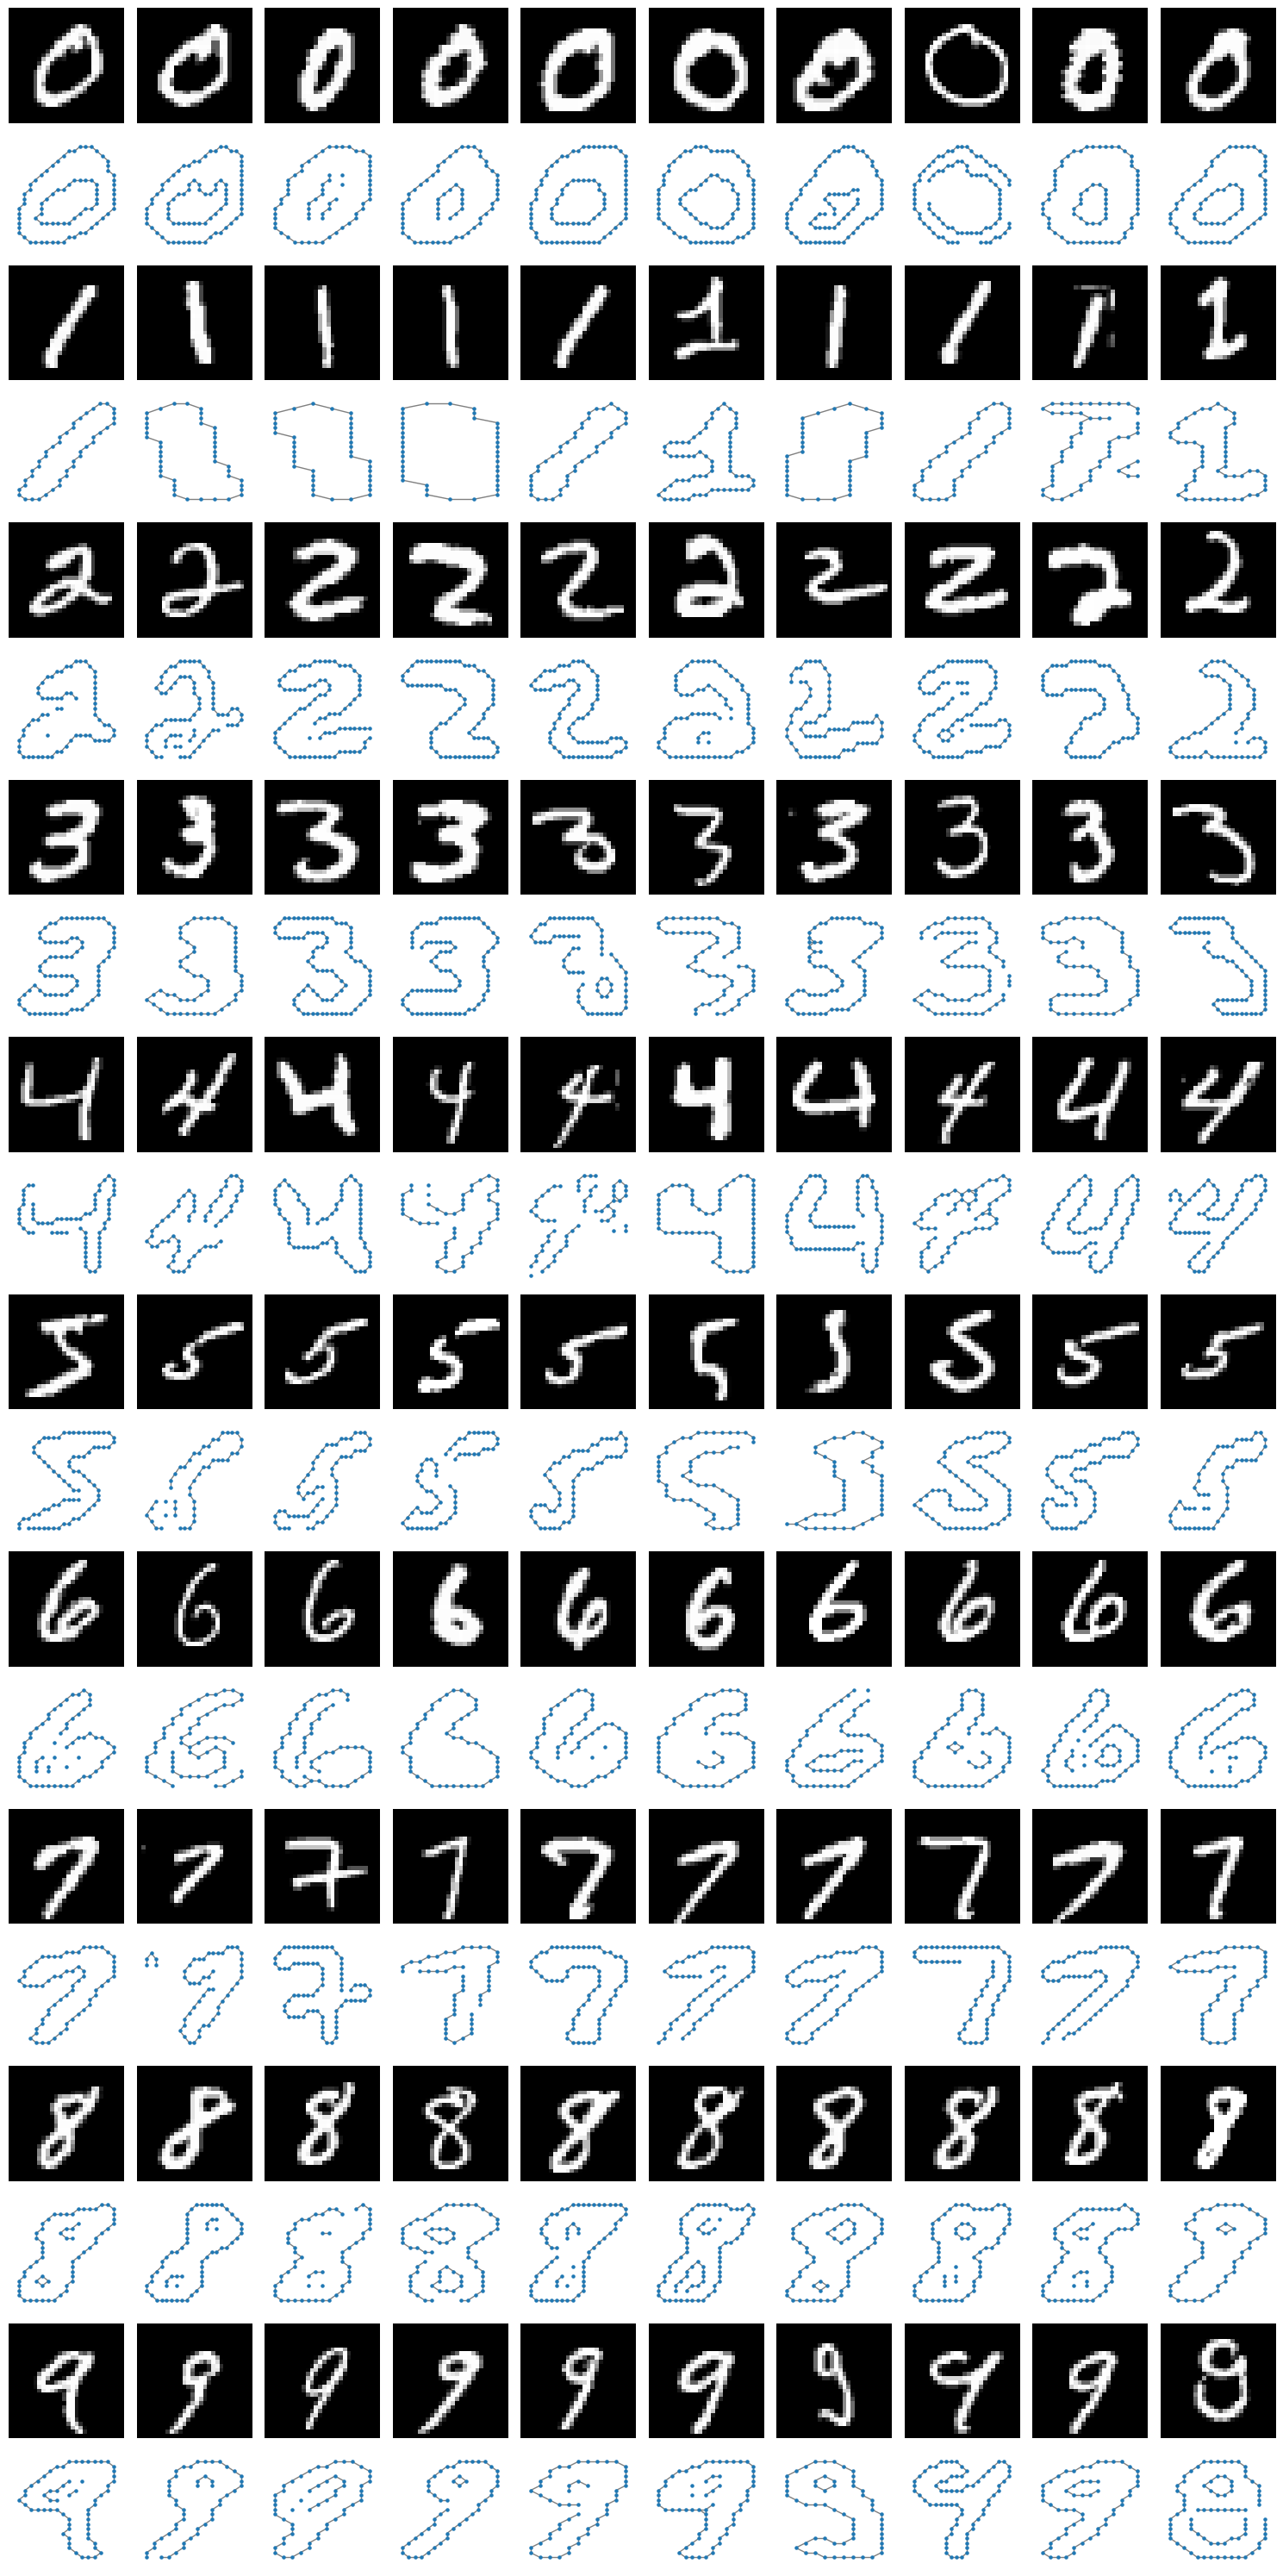

In [124]:
# Create a figure with 20 rows (10 digits, each with image + graph) and 10 columns
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
    
        ## second graph
        graph2 = mnist_to_graph(image)
        plot_graph(graph2, axes[2 * i + 1, j])

        axes[2 * i + 1, j].axis('off')



plt.tight_layout()
plt.show()

## 03. Split the graph into vertical and horizontal oriented

First node:  (np.int64(12), np.int64(-4))


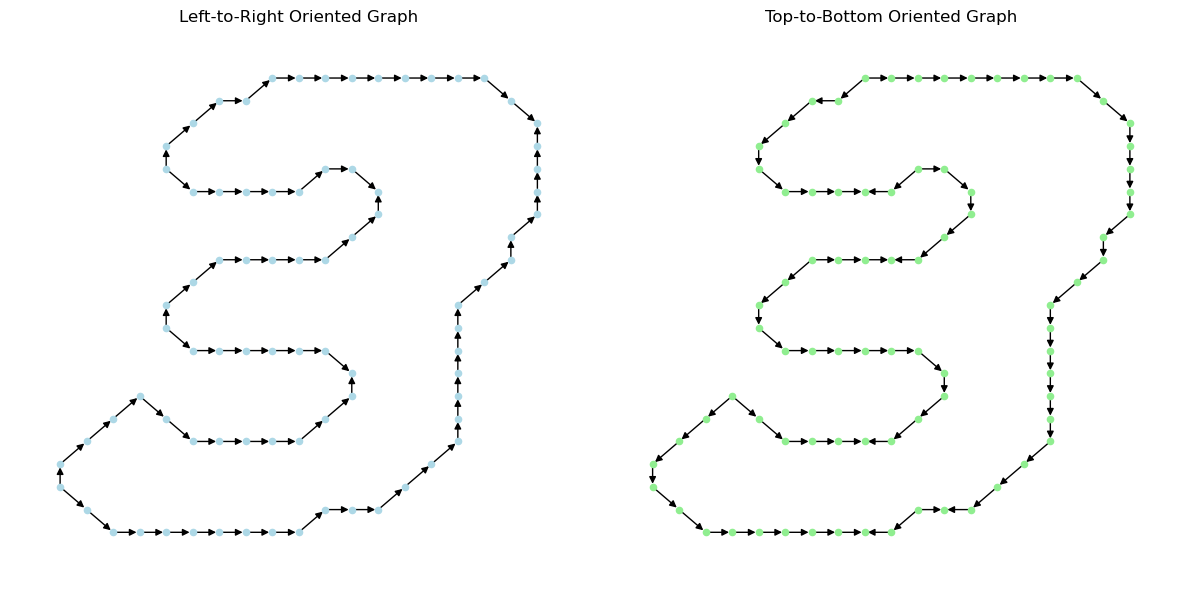

In [125]:
# First derived graph: Left-to-Right oriented
G_lr = nx.DiGraph()
positions = nx.get_node_attributes(G, 'pos')
for u, v in G.edges():
    if positions[u][0] < positions[v][0]:
        G_lr.add_edge(u, v)
    else:
        G_lr.add_edge(v, u)

# Second derived graph: Top-to-Bottom oriented
G_td = nx.DiGraph()
for u, v in G.edges():
    if positions[u][1] < positions[v][1]:
        G_td.add_edge(v, u)  # from top (lower y) to bottom (higher y)
    else:
        G_td.add_edge(u, v)

# Draw the graphs
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Left-to-Right Graph
nx.draw(G_lr, pos=positions, with_labels=False, ax=axs[0], node_color='lightblue', node_size=20, edge_color='black', arrows=True)

print("First node: ", list(G_lr.nodes())[0])
axs[0].set_title("Left-to-Right Oriented Graph")

# Top-to-Bottom Graph
nx.draw(G_td, pos=positions, with_labels=False, ax=axs[1], node_color='lightgreen', node_size=20, edge_color='black', arrows=True)
axs[1].set_title("Top-to-Bottom Oriented Graph")

plt.tight_layout()
plt.show()

## 04. Extract directed paths

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


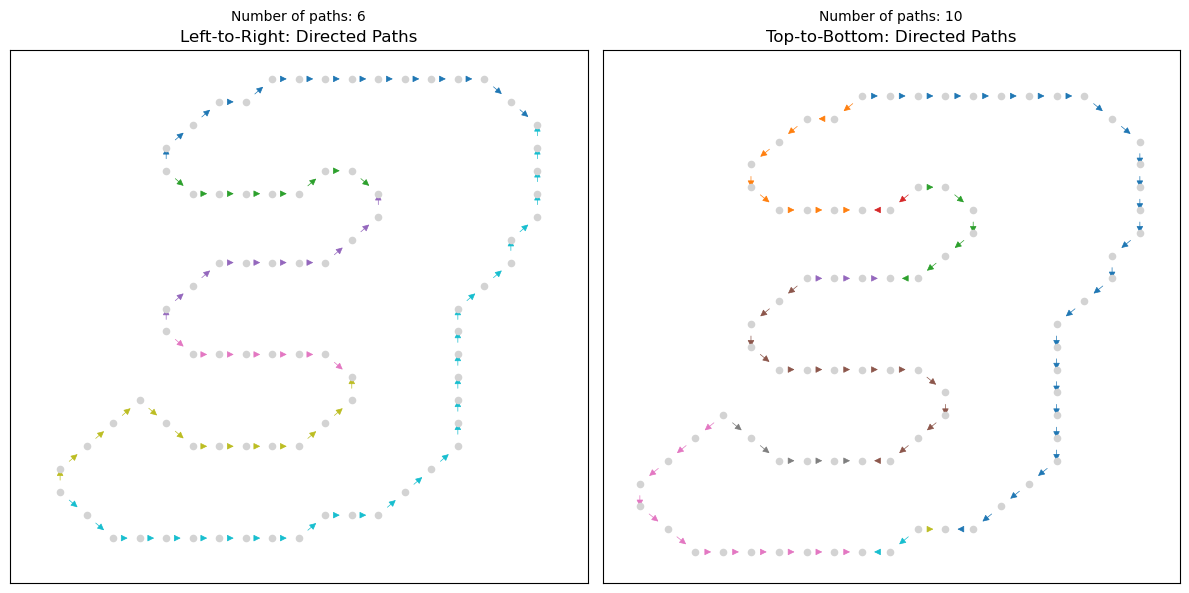

In [126]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random

def extract_directed_paths(G_dir):
    visited_edges = set()
    paths = []

    def dfs_path(current, path):
        path.append(current)
        successors = list(G_dir.successors(current))
        if len(successors) != 1:
            return  # Stop if there's a branch or end
        next_node = successors[0]
        edge = (current, next_node)
        if edge not in visited_edges:
            visited_edges.add(edge)
            dfs_path(next_node, path)

    start_nodes = [n for n in G_dir.nodes if G_dir.in_degree(n) == 0]
    #print(f"Start nodes: {start_nodes}")

    # #plot start nodes
    # plt.figure(figsize=(6, 6))
    # nx.draw(G_dir, pos=positions, with_labels=False, node_size=20,
    #         node_color='lightgray', edge_color='black', arrows=True)
    # nx.draw_networkx_nodes(G_dir, pos=positions, nodelist=start_nodes,
    #                        node_color='red', node_size=50, label='Start Nodes')
    # plt.title("Start Nodes in Directed Graph")
    # plt.legend()
    # plt.show()

    for node in start_nodes:
        for succ in G_dir.successors(node):
            edge = (node, succ)
            if edge not in visited_edges:
                visited_edges.add(edge)
                path = [node]
                dfs_path(succ, path)
                if len(path) > 1:
                    paths.append(path)
                    #print(f"Extracted path: {path}")

    return paths




def plot_graph_with_paths(G_dir, paths, positions, ax, title, node_size=20, verbose=True):
    #fig, ax = plt.subplots(figsize=(6, 6))
    colors = cm.get_cmap('tab10', len(paths))

    # Draw all nodes first
    nx.draw_networkx_nodes(G_dir, pos=positions, node_size=node_size, node_color='lightgray', ax=ax)

    # Draw paths in distinct colors
    for i, path in enumerate(paths):
        edge_list = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(
            G_dir,
            pos=positions,
            edgelist=edge_list,
            edge_color=[colors(i)],
            width=0.5,
            arrows=True,
            ax=ax
        )
    # Set title and number of paths
    ax.set_title(title, fontsize=12)
    if verbose:
        ax.text(0.5, 1.05, f"Number of paths: {len(paths)}",
                transform=ax.transAxes,
                ha='center', fontsize=10, verticalalignment='bottom')



# Process left-to-right graph
# Draw the graphs
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

lr_paths = extract_directed_paths(G_lr)
plot_graph_with_paths(G_lr, lr_paths, positions, axs[0], "Left-to-Right: Directed Paths")

# Process top-to-bottom graph
td_paths = extract_directed_paths(G_td)
plot_graph_with_paths(G_td, td_paths, positions, axs[1], "Top-to-Bottom: Directed Paths")

plt.tight_layout()
plt.show()

## 05. Merge edges with similar orientation

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


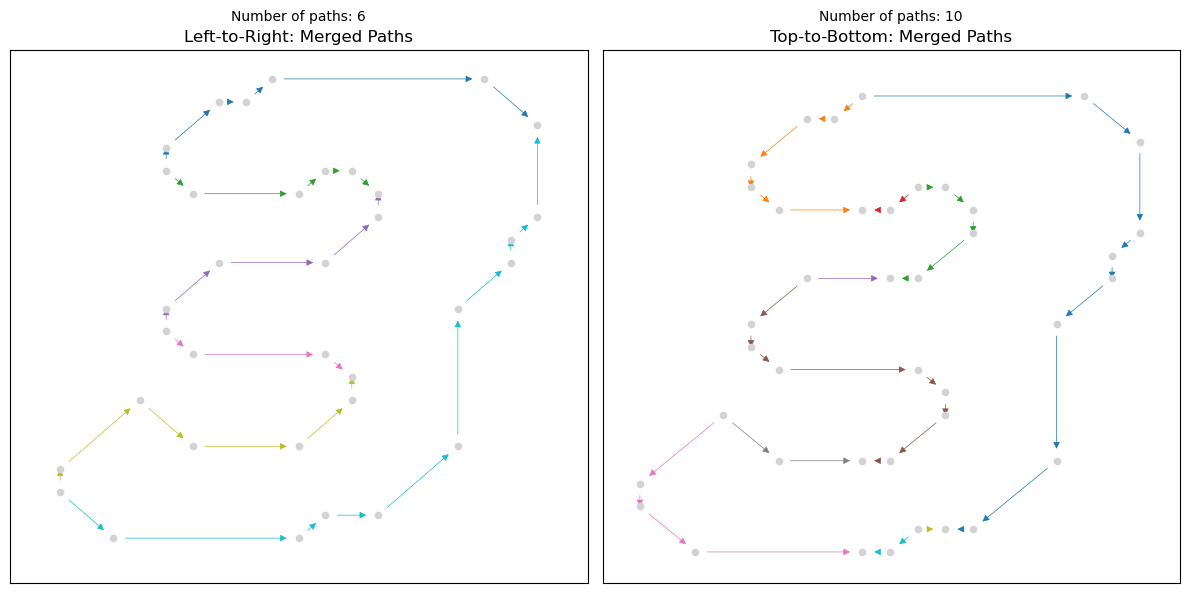

In [127]:
def merge_similar_edges_from_paths(G_dir, paths, positions, angle_threshold=10):
    """
    Merges only the edges along each directed path that are nearly aligned.
    
    :param G_dir: Directed graph with 'pos' attributes.
    :param paths: List of paths (each path is a list of nodes).
    :param positions: Dict of node positions.
    :param angle_threshold: Angular threshold (in degrees) to merge edges.
    :return: A new directed graph with merged edges and position info.
    """
    import numpy as np
    import networkx as nx

    merged_G = nx.DiGraph()
    pos = positions

    def angle_between(v1, v2):
        cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

    for path in paths:
        if len(path) < 2:
            continue

        i = 0
        while i < len(path) - 1:
            u = path[i]
            v = path[i + 1]
            origin = np.array(pos[u])
            direction = np.array(pos[v]) - origin
            merged_origin = origin.copy()
            merged_direction = direction.copy()
            total_length = np.linalg.norm(direction)
            current_path = [(u, v)]

            j = i + 1
            while j < len(path) - 1:
                curr = path[j]
                nxt = path[j + 1]
                next_dir = np.array(pos[nxt]) - np.array(pos[curr])
                angle = angle_between(merged_direction, next_dir)
                if angle < angle_threshold:
                    merged_direction += next_dir
                    total_length += np.linalg.norm(next_dir)
                    current_path.append((curr, nxt))
                    j += 1
                else:
                    break

            endpoint = merged_origin + merged_direction
            merged_G.add_edge(tuple(merged_origin), tuple(endpoint),
                              length=total_length, original_edges=current_path)

            # Set node positions
            merged_G.nodes[tuple(merged_origin)]['pos'] = merged_origin
            merged_G.nodes[tuple(endpoint)]['pos'] = endpoint

            i = j

    return merged_G


def draw_merged_graph(ax, merged_G, title):
    pos_merged = nx.get_node_attributes(merged_G, 'pos')
    nx.draw(merged_G, pos=pos_merged, ax=ax,
            with_labels=False, arrows=True,
            edge_color='blue', node_size=10, arrowstyle='->')
    ax.set_title(title)


# ---- APPLY TO BOTH GRAPHS ----

# Extract paths
lr_paths = extract_directed_paths(G_lr)
td_paths = extract_directed_paths(G_td)

# Merge aligned edges within paths
merged_G_lr = merge_similar_edges_from_paths(G_lr, lr_paths, positions, angle_threshold=10)
merged_G_td = merge_similar_edges_from_paths(G_td, td_paths, positions, angle_threshold=10)

lr_paths = extract_directed_paths(merged_G_lr)
td_paths = extract_directed_paths(merged_G_td)

# Plot merged directed graphs
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

pos_merged_lr = nx.get_node_attributes(merged_G_lr, 'pos')
pos_merged_td = nx.get_node_attributes(merged_G_td, 'pos')

plot_graph_with_paths(merged_G_lr, lr_paths, pos_merged_lr, axs[0], "Left-to-Right: Merged Paths")
plot_graph_with_paths(merged_G_td, td_paths, pos_merged_td, axs[1], "Top-to-Bottom: Merged Paths")

plt.tight_layout()
plt.show()


### Show the difference with various smoothing angles

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


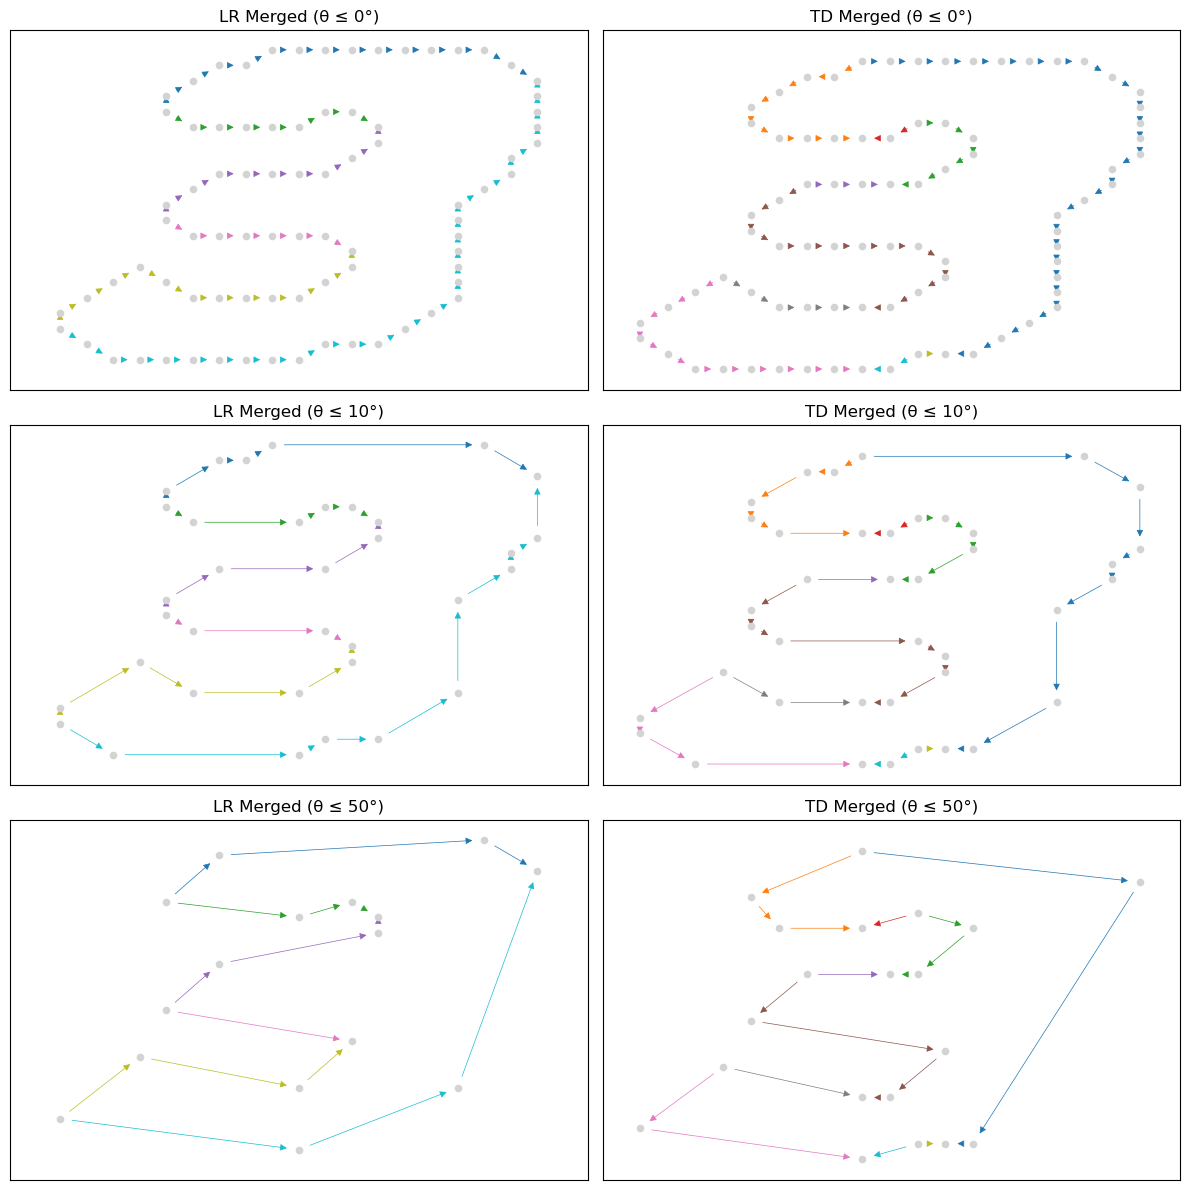

In [128]:
# Merge and visualize for different thresholds
thresholds = [0, 10, 50]
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

for i, angle_threshold in enumerate(thresholds):
    # Left-to-right
    lr_paths = extract_directed_paths(G_lr)
    merged_lr = merge_similar_edges_from_paths(G_lr, lr_paths, positions, angle_threshold)
    pos_lr = nx.get_node_attributes(merged_lr, "pos")
    lr_paths = extract_directed_paths(merged_lr)

    plot_graph_with_paths(merged_lr, lr_paths, pos_lr, axs[i, 0], f"LR Merged (θ ≤ {angle_threshold}°)", verbose=False)

    # Top-to-bottom
    td_paths = extract_directed_paths(G_td)
    merged_td = merge_similar_edges_from_paths(G_td, td_paths, positions, angle_threshold)
    pos_td = nx.get_node_attributes(merged_td, "pos")
    td_paths = extract_directed_paths(merged_td)
    plot_graph_with_paths(merged_td, td_paths, pos_td, axs[i, 1], f"TD Merged (θ ≤ {angle_threshold}°)", verbose=False)

plt.tight_layout()
plt.show()

### Show for all digits, smoothing thereshold = $0.0$

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


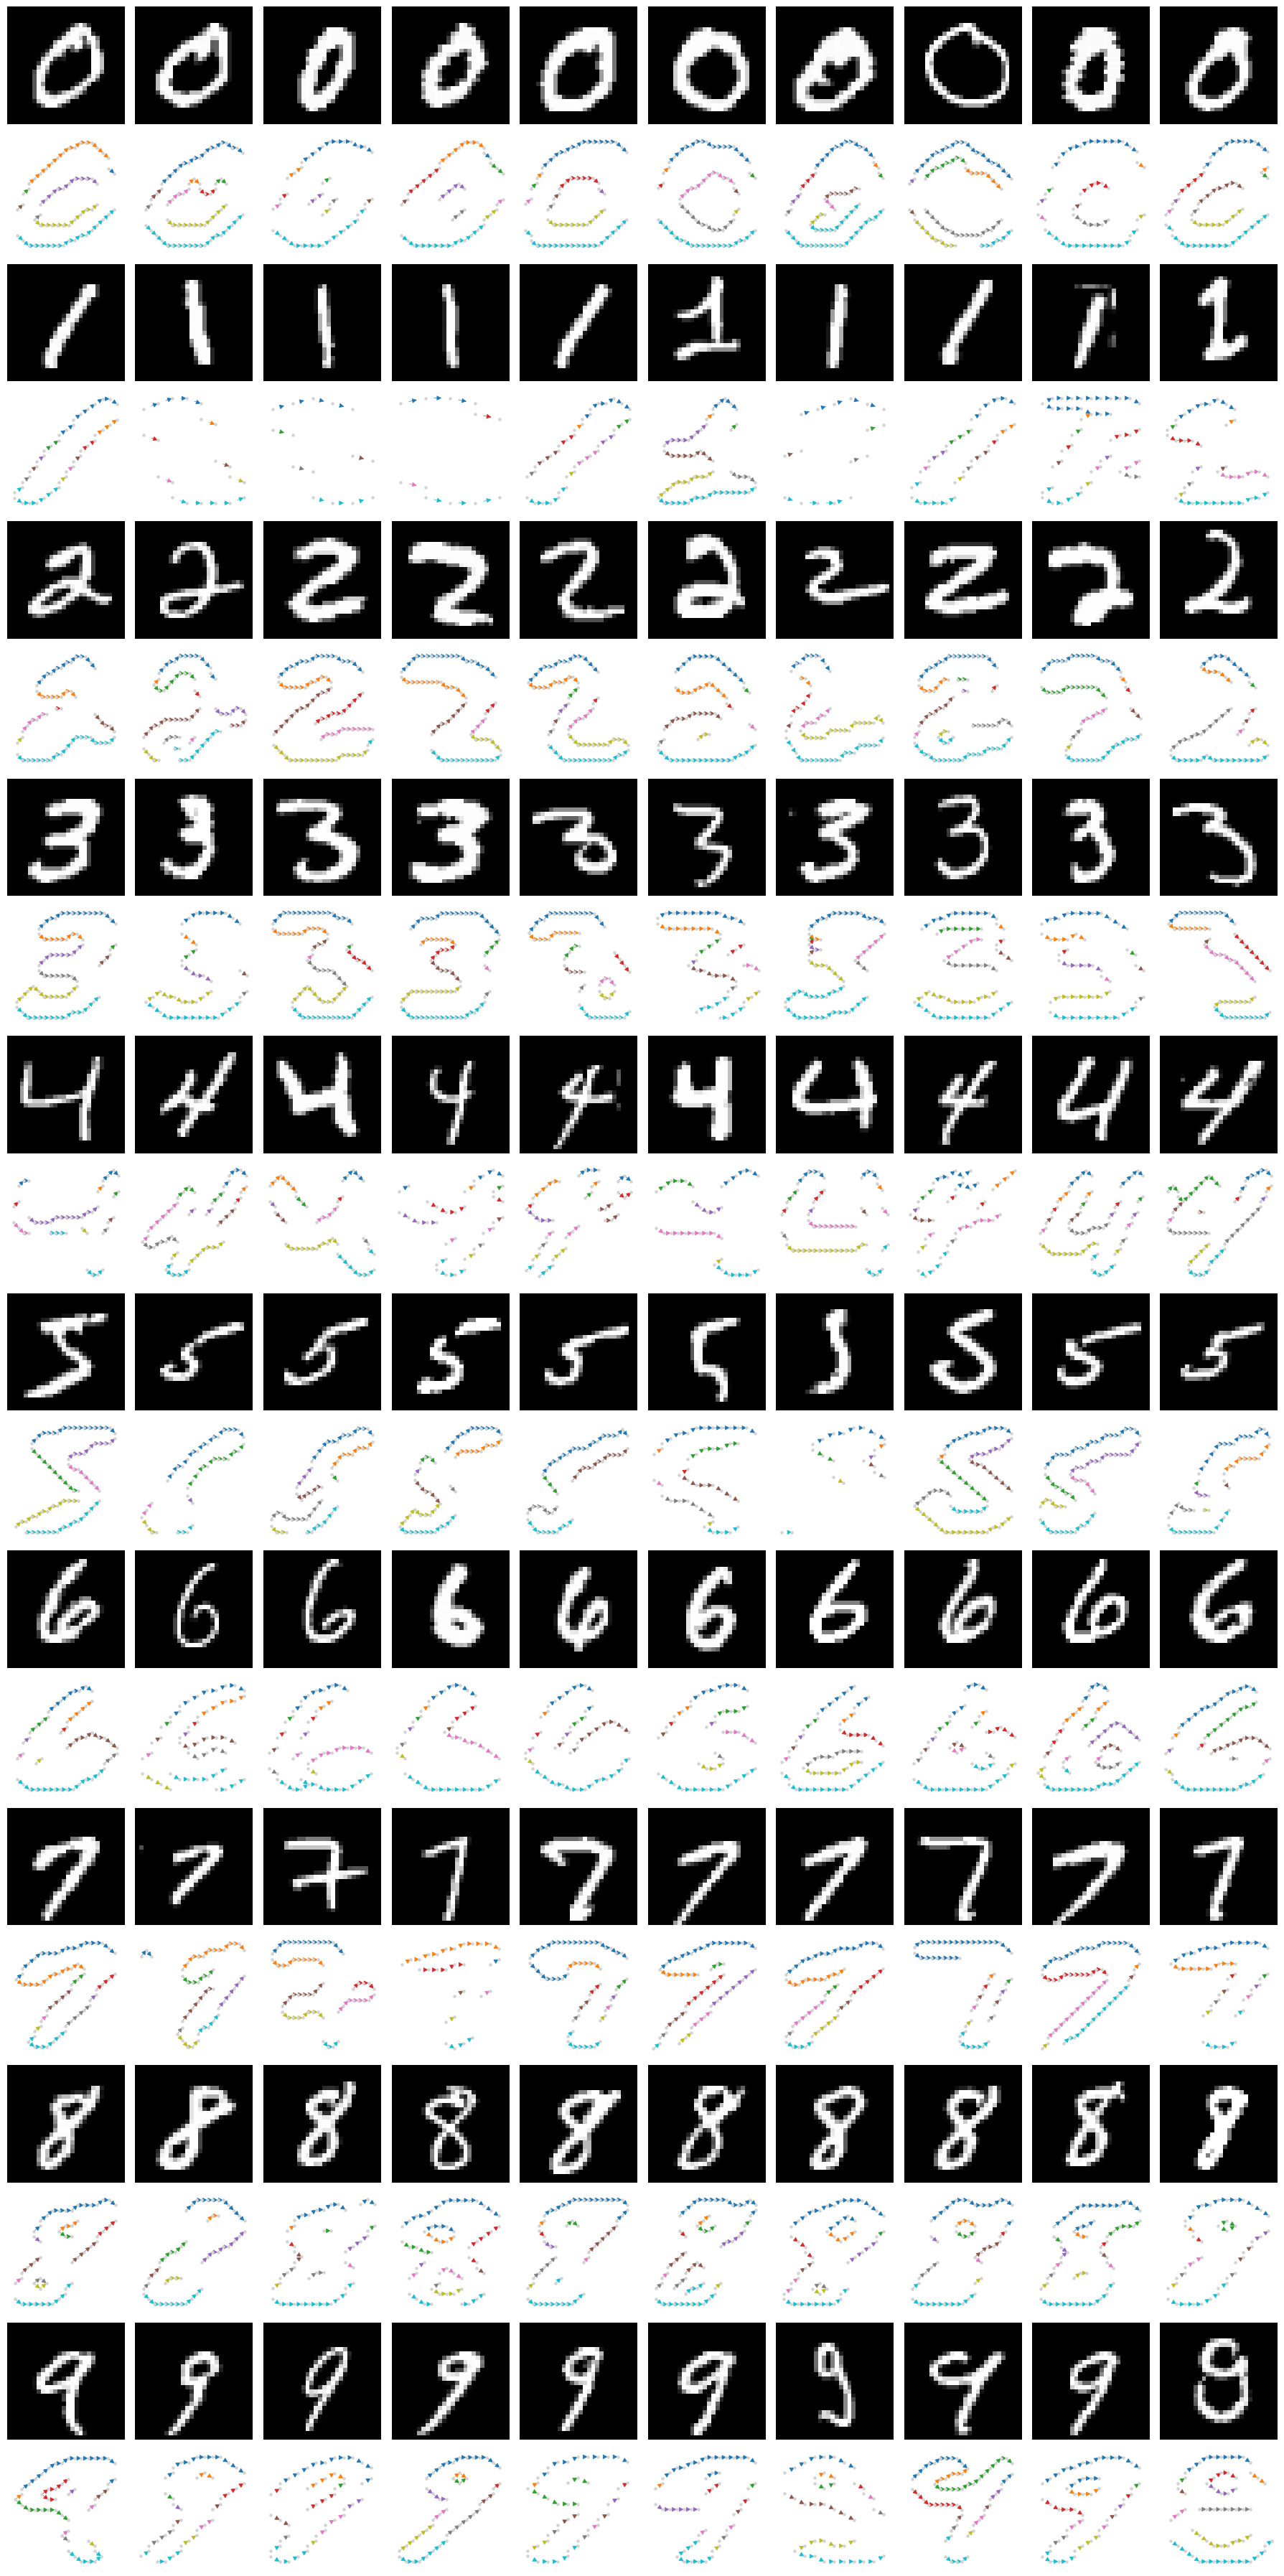

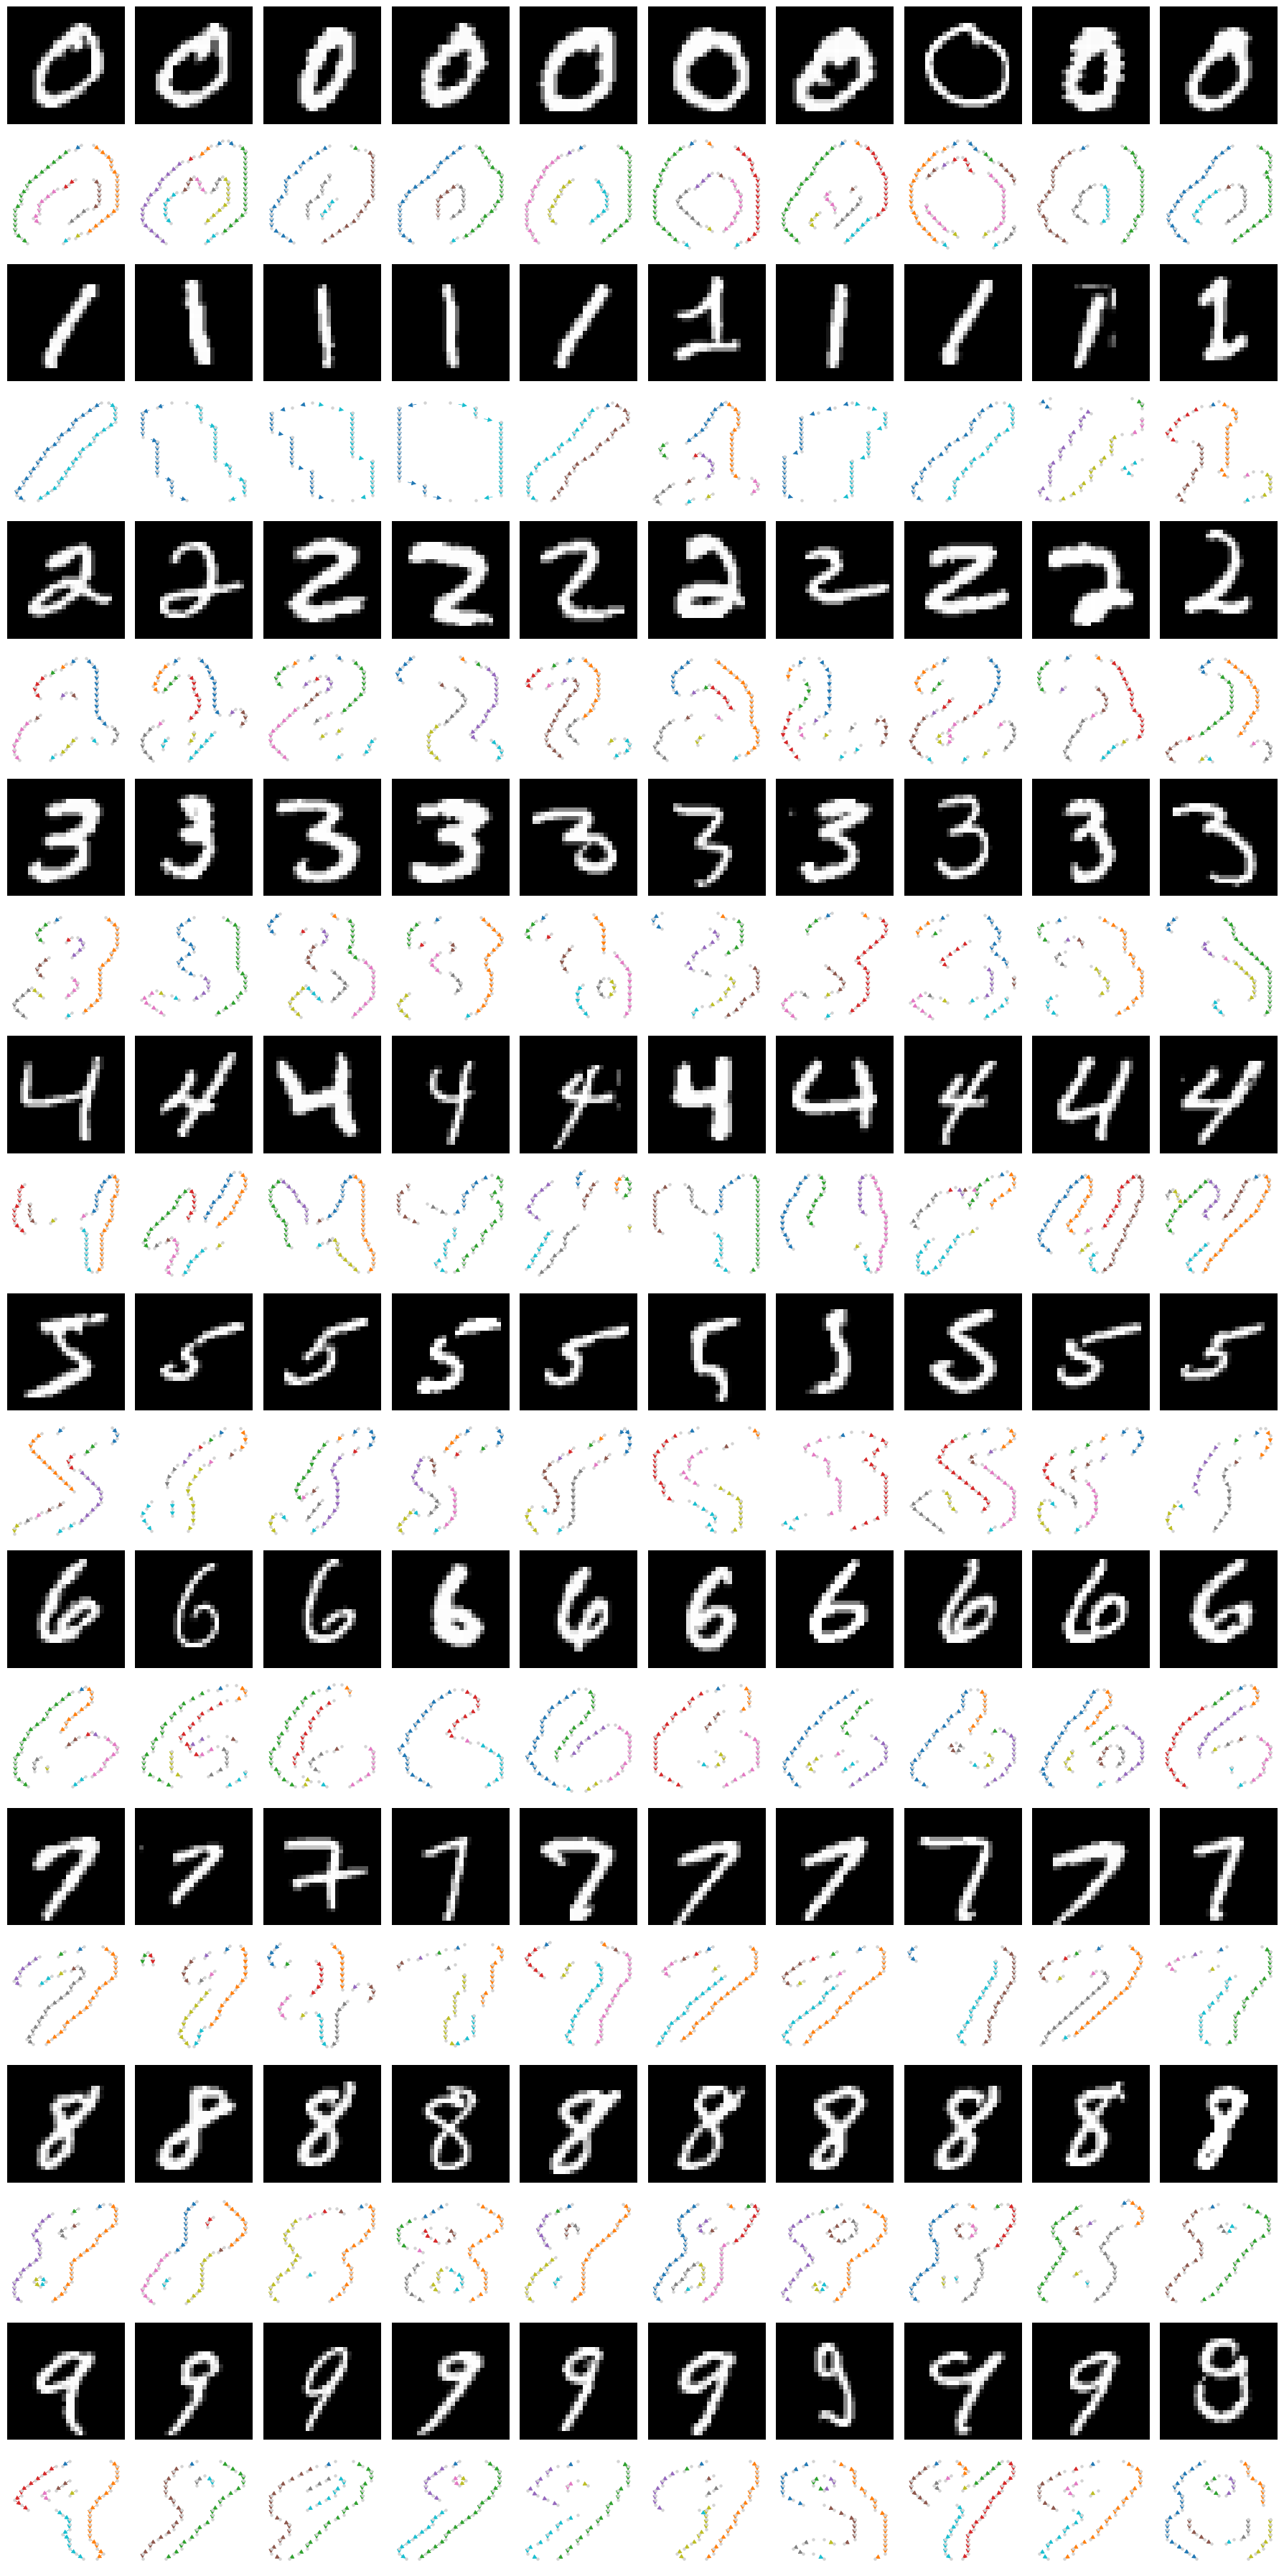

In [131]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Replace with your digit loading
from keras.datasets import mnist

# Create left-right and top-down versions
def build_directed_graphs(G):
    pos = nx.get_node_attributes(G, "pos")
    G_lr = nx.DiGraph()
    G_td = nx.DiGraph()

    for u, v in G.edges():
        pu, pv = pos[u], pos[v]
        if pu[0] < pv[0]:  # left to right
            G_lr.add_edge(u, v)
        elif pu[0] > pv[0]:
            G_lr.add_edge(v, u)

        if pu[1] < pv[1]:  # top to bottom
            G_td.add_edge(v, u)
        elif pu[1] > pv[1]:
            G_td.add_edge(u, v)

    nx.set_node_attributes(G_lr, pos, "pos")
    nx.set_node_attributes(G_td, pos, "pos")
    return G_lr, G_td

# Use your existing merging and path plotting functions:
# - extract_directed_paths
# - merge_similar_edges_from_paths
# - plot_graph_with_paths

fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        G_lr, _ = build_directed_graphs(G)
        positions = nx.get_node_attributes(G_lr, 'pos')

        paths = extract_directed_paths(G_lr)
        merged_G = merge_similar_edges_from_paths(G_lr, paths, positions, angle_threshold=0)
        merged_paths = extract_directed_paths(merged_G)
        merged_positions = nx.get_node_attributes(merged_G, 'pos')

        plot_graph_with_paths(merged_G, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        _, G_td = build_directed_graphs(G)
        positions = nx.get_node_attributes(G_td, 'pos')

        paths = extract_directed_paths(G_td)
        merged_G = merge_similar_edges_from_paths(G_td, paths, positions, angle_threshold=0)
        merged_paths = extract_directed_paths(merged_G)
        merged_positions = nx.get_node_attributes(merged_G, 'pos')

        plot_graph_with_paths(merged_G, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()


### Show for all digits, smoothing thereshold = $10.0$

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


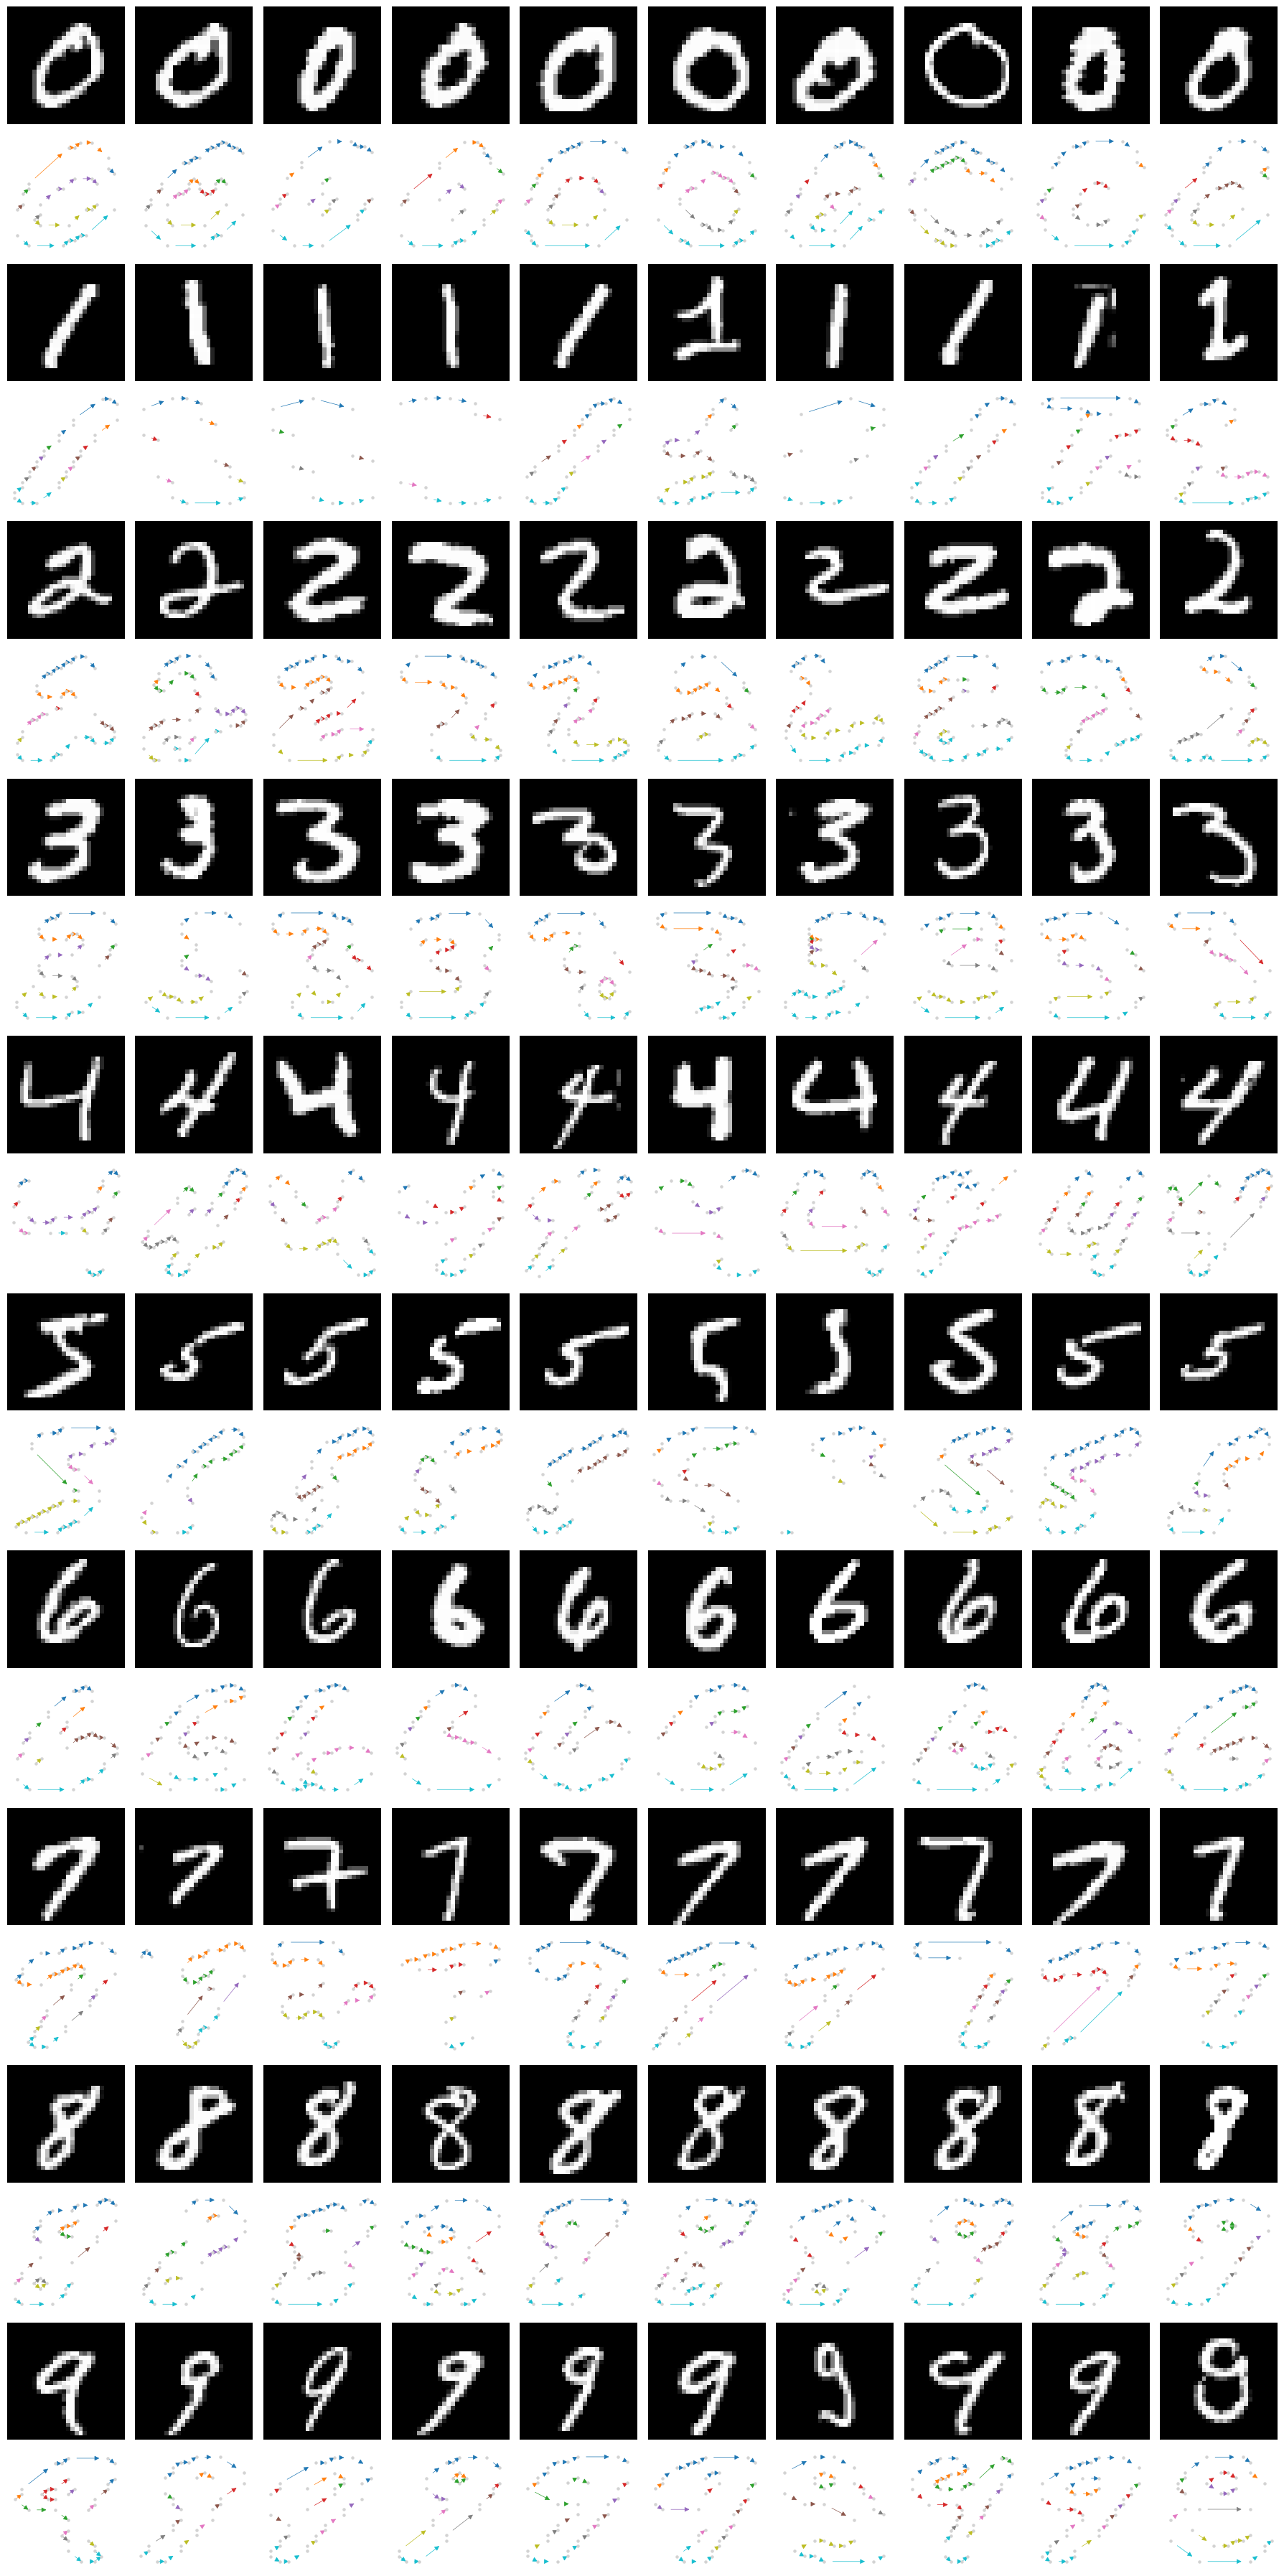

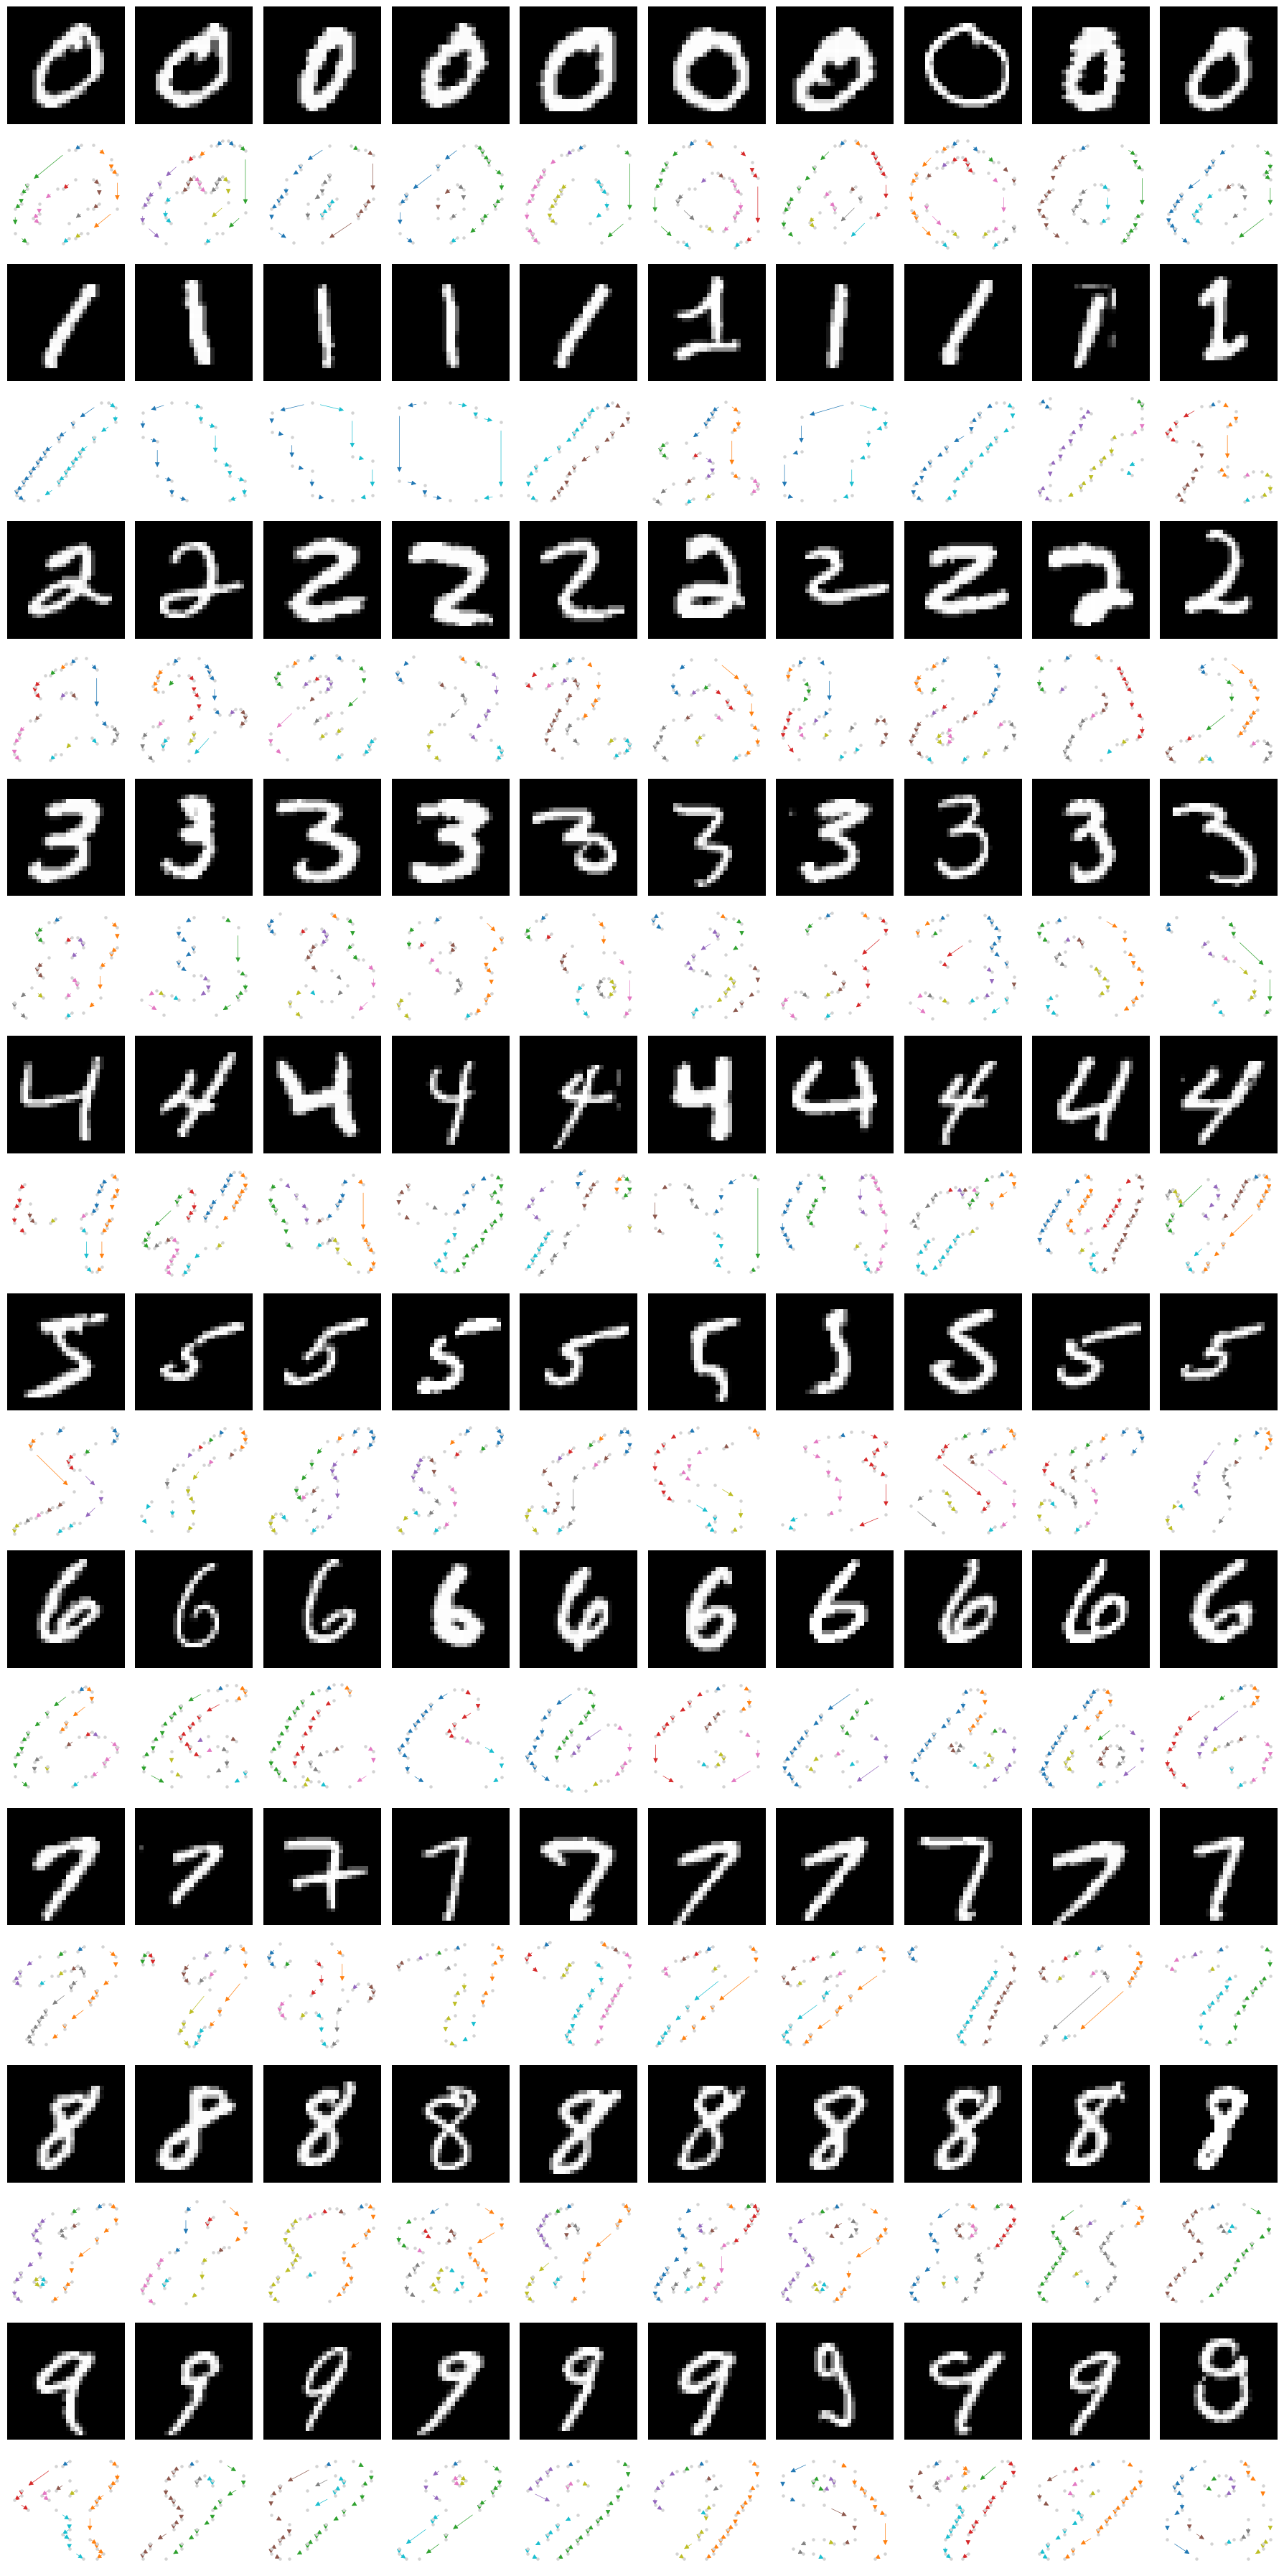

In [134]:
fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        G_lr, _ = build_directed_graphs(G)
        positions = nx.get_node_attributes(G_lr, 'pos')

        paths = extract_directed_paths(G_lr)
        merged_G = merge_similar_edges_from_paths(G_lr, paths, positions, angle_threshold=10)
        merged_paths = extract_directed_paths(merged_G)
        merged_positions = nx.get_node_attributes(merged_G, 'pos')

        plot_graph_with_paths(merged_G, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        _, G_td = build_directed_graphs(G)
        positions = nx.get_node_attributes(G_td, 'pos')

        paths = extract_directed_paths(G_td)
        merged_G = merge_similar_edges_from_paths(G_td, paths, positions, angle_threshold=10)
        merged_paths = extract_directed_paths(merged_G)
        merged_positions = nx.get_node_attributes(merged_G, 'pos')

        plot_graph_with_paths(merged_G, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()

### Show for all digits, smoothing thereshold = $50.0$

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


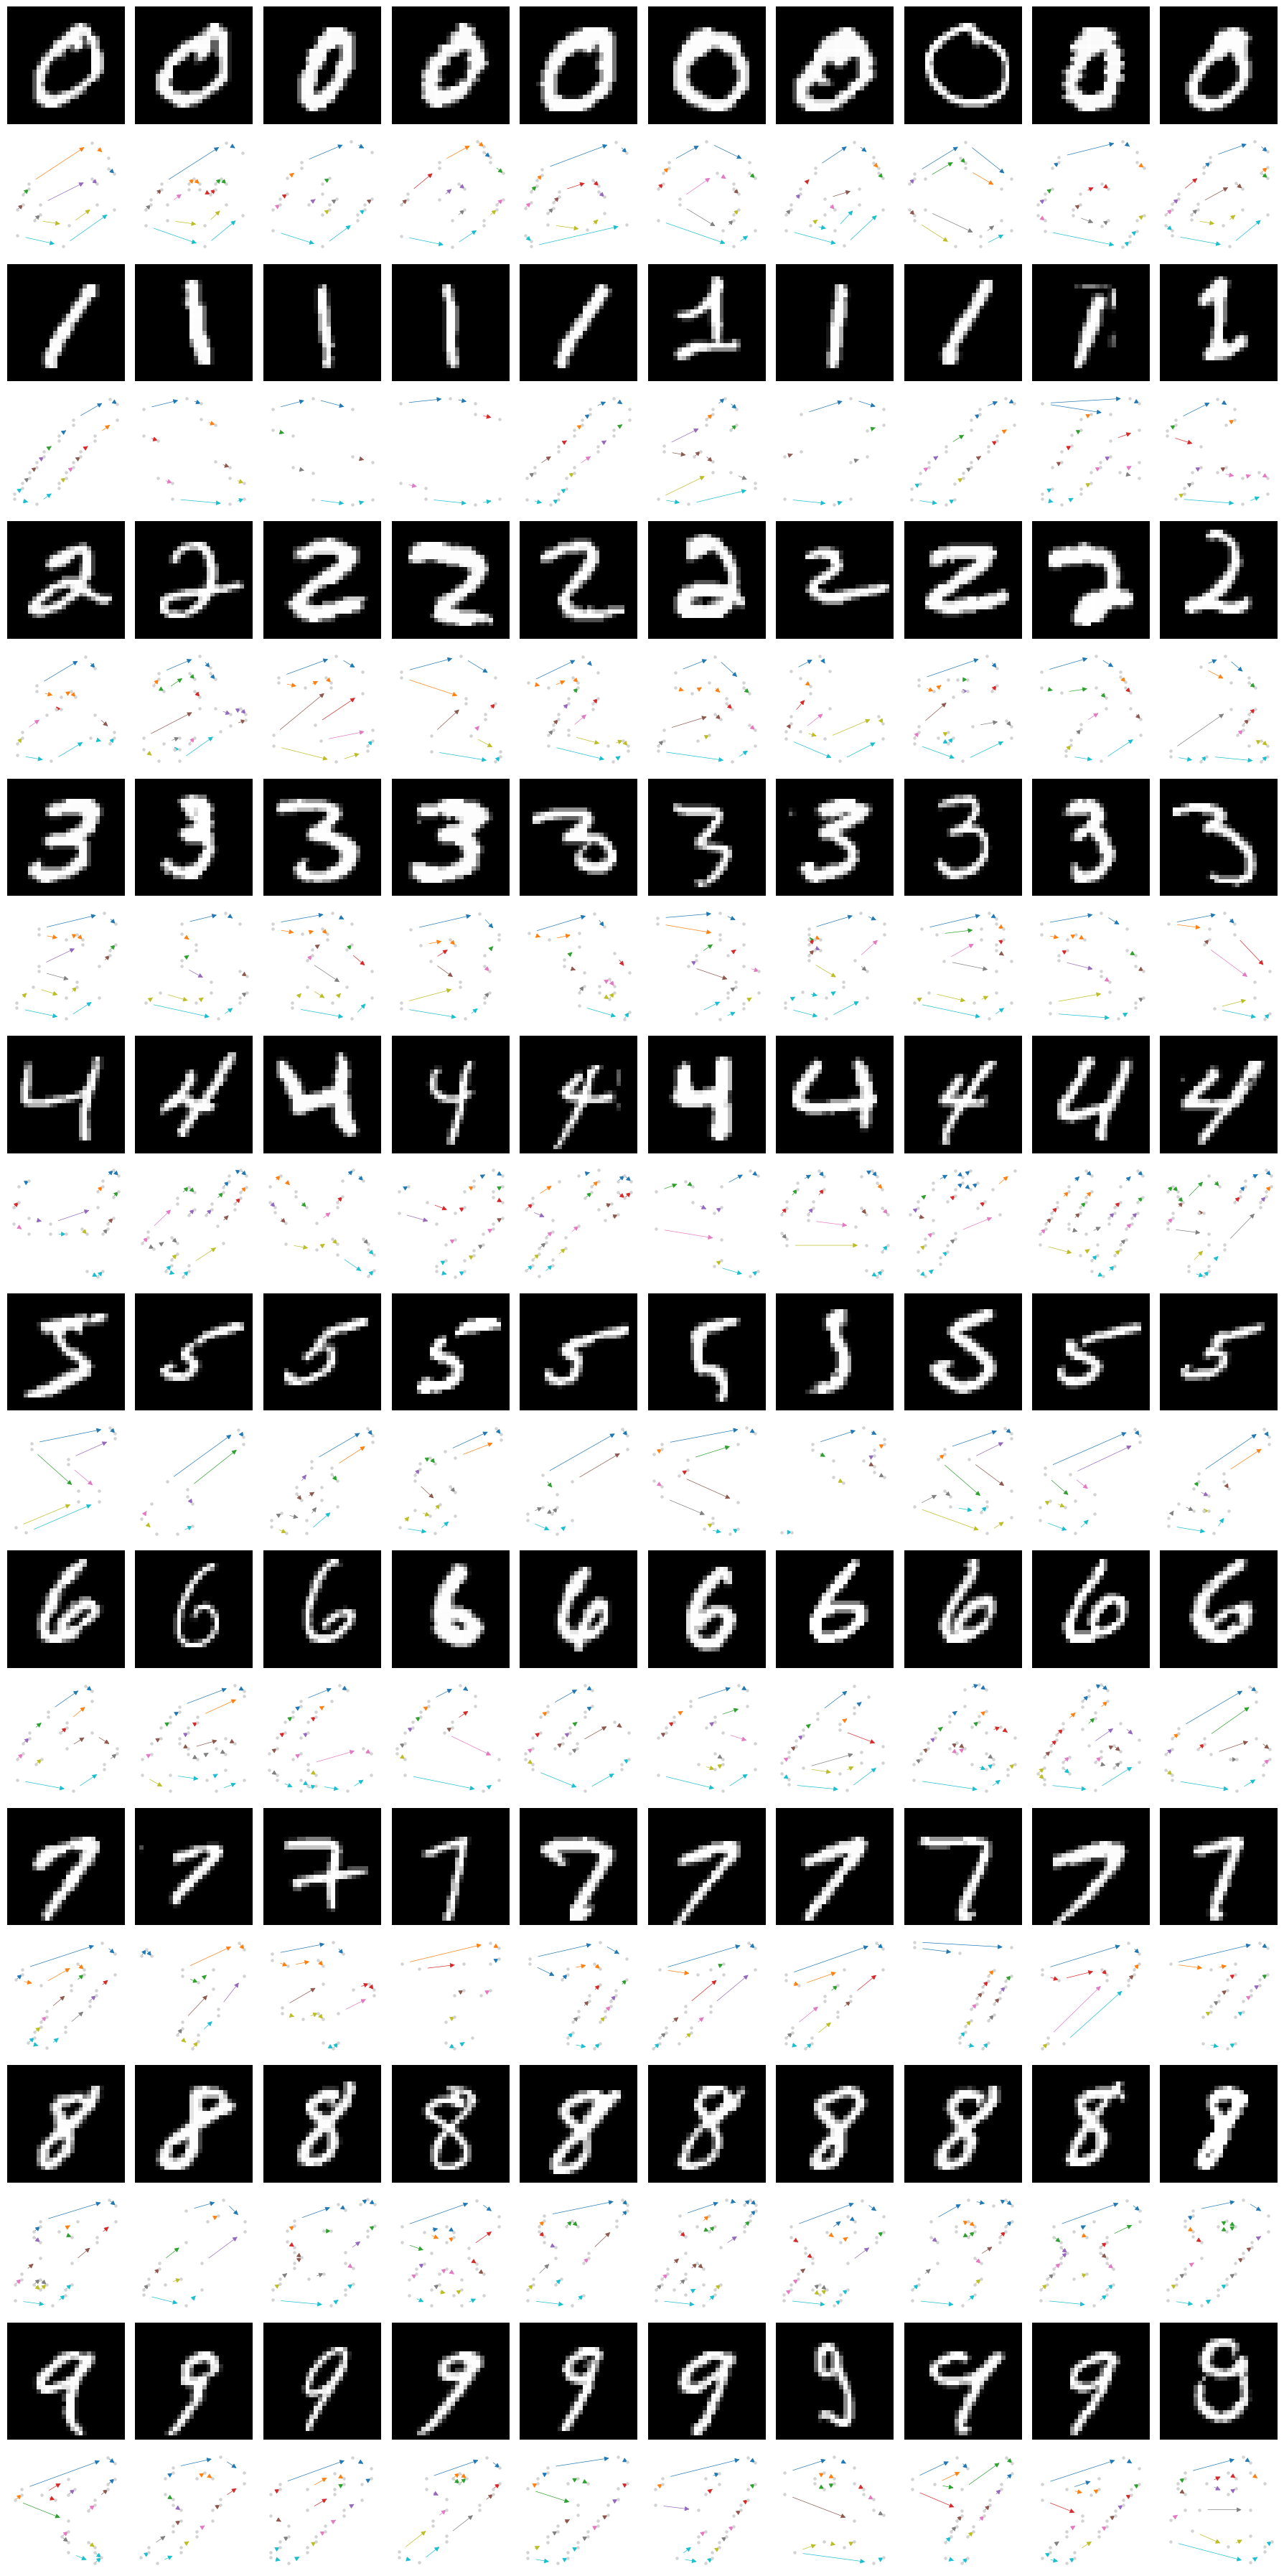

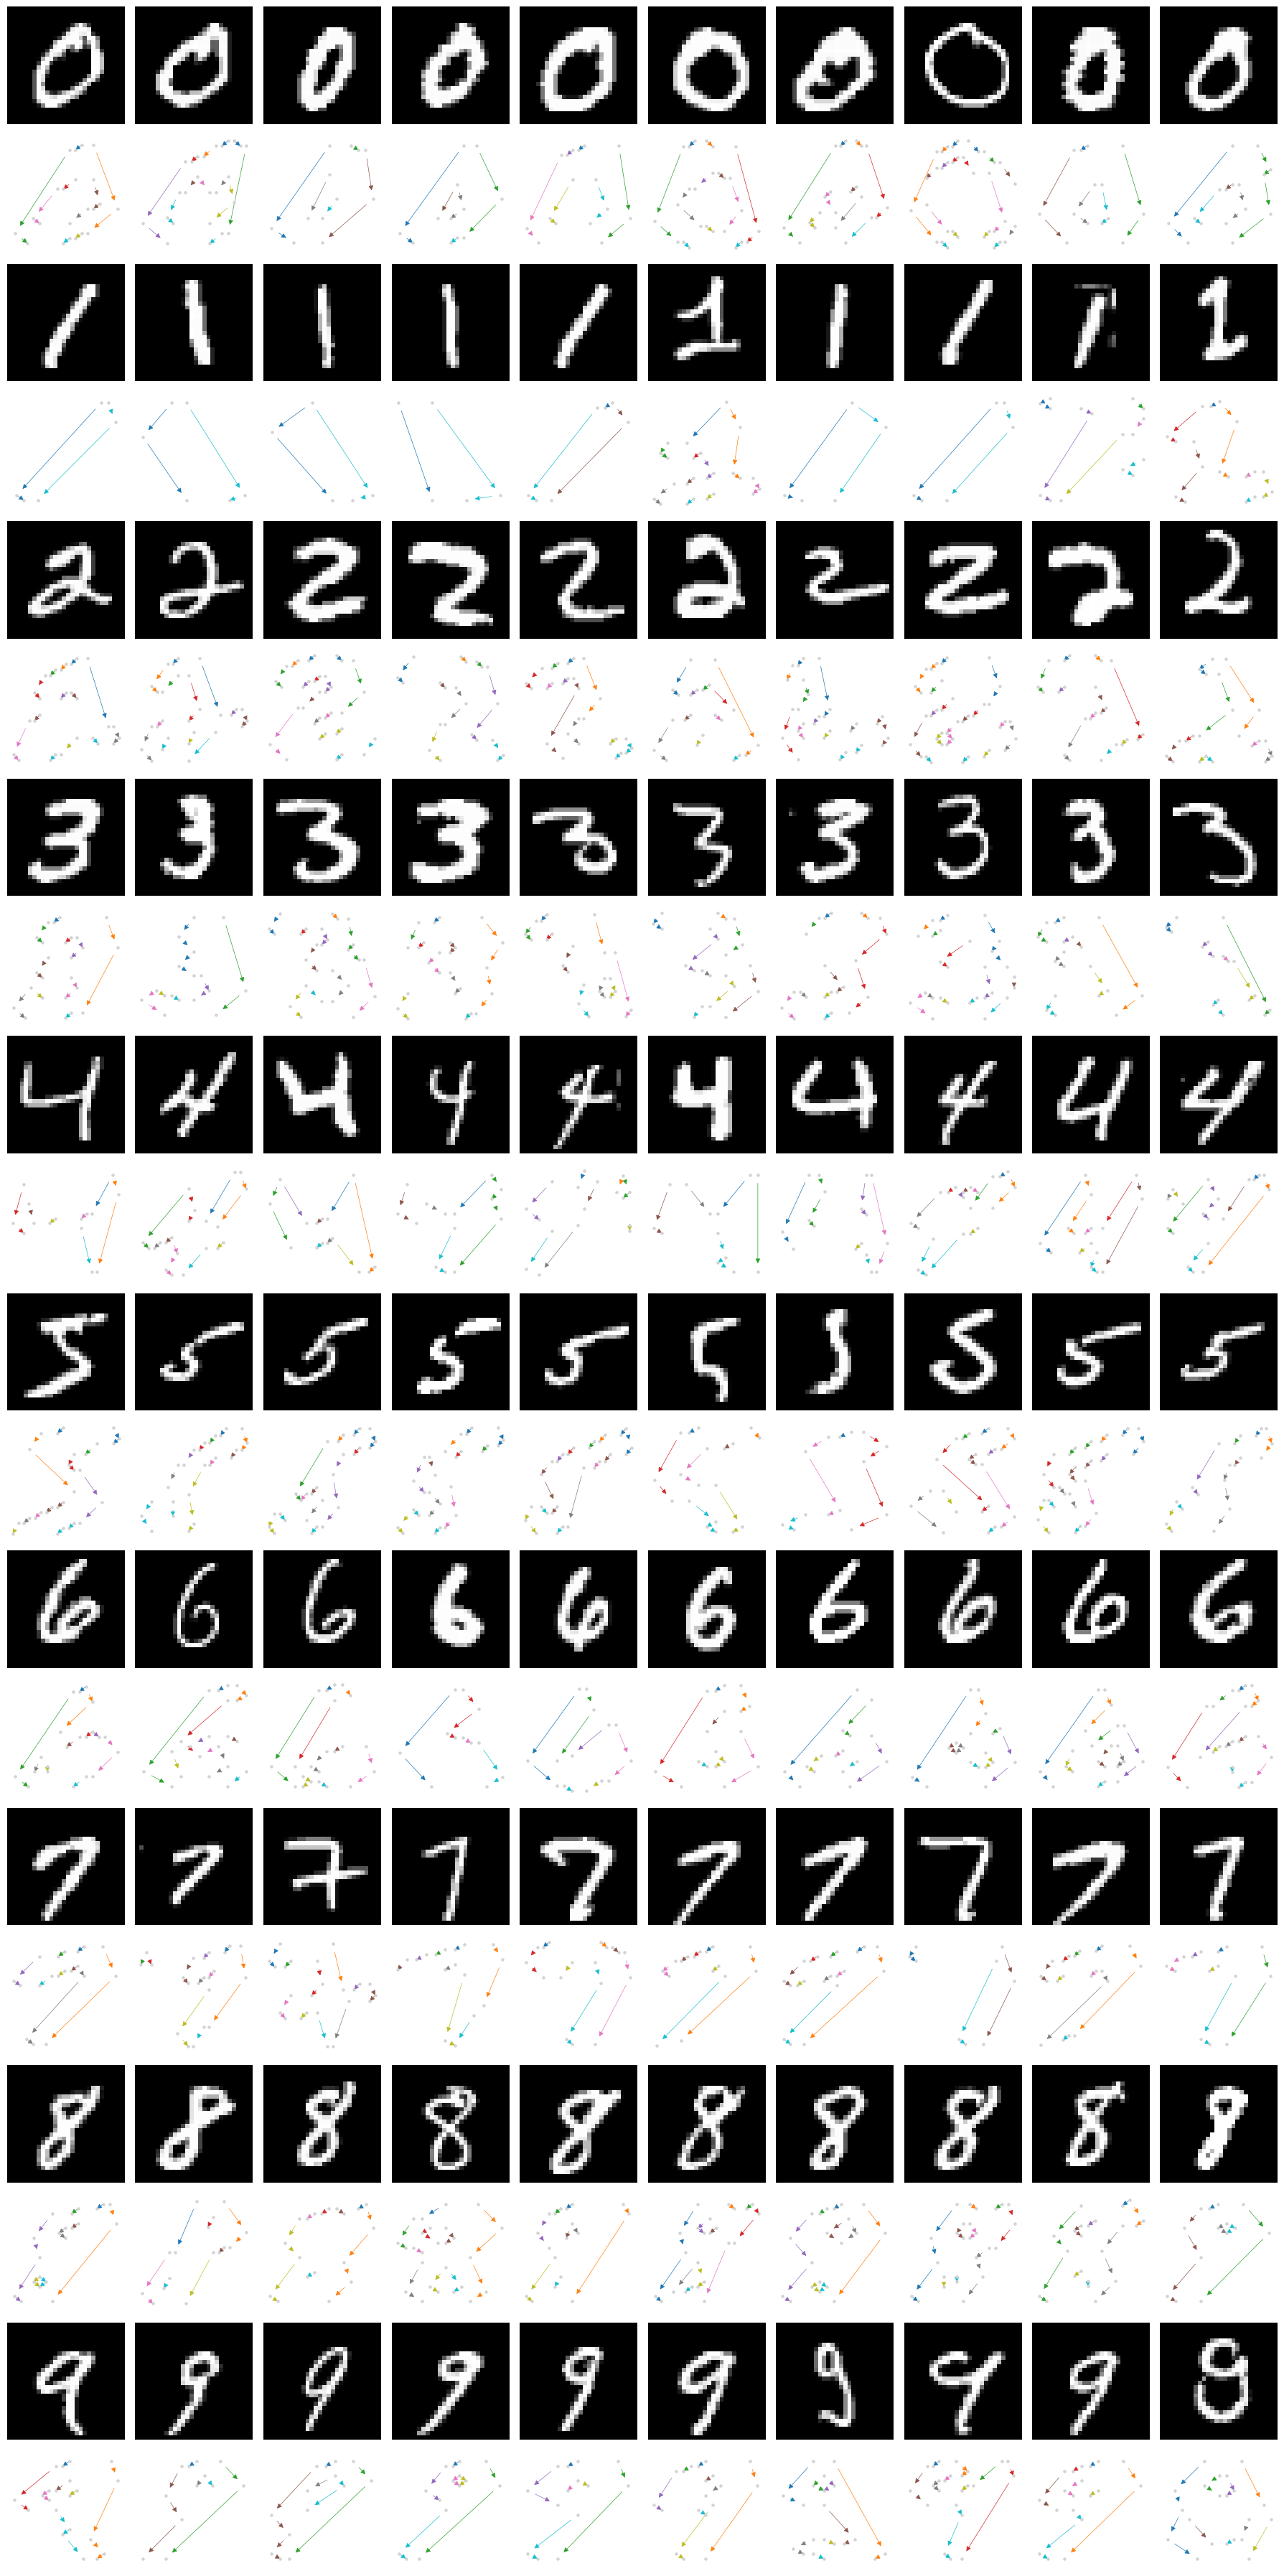

In [ ]:
fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        G_lr, _ = build_directed_graphs(G)
        positions = nx.get_node_attributes(G_lr, 'pos')

        paths = extract_directed_paths(G_lr)
        merged_G = merge_similar_edges_from_paths(G_lr, paths, positions, angle_threshold=50)
        merged_paths = extract_directed_paths(merged_G)
        merged_positions = nx.get_node_attributes(merged_G, 'pos')

        plot_graph_with_paths(merged_G, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        _, G_td = build_directed_graphs(G)
        positions = nx.get_node_attributes(G_td, 'pos')

        paths = extract_directed_paths(G_td)
        merged_G = merge_similar_edges_from_paths(G_td, paths, positions, angle_threshold=50)
        merged_paths = extract_directed_paths(merged_G)
        merged_positions = nx.get_node_attributes(merged_G, 'pos')

        plot_graph_with_paths(merged_G, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()

## 06. First Smooth them extract paths

(Change of approach):
- Before: 
    1. Extract paths
    2. Smooth paths

- Now: 
    1. Smooth graph
    2. Extract paths

### Show for all digits, smoothing thereshold = $10.0$

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


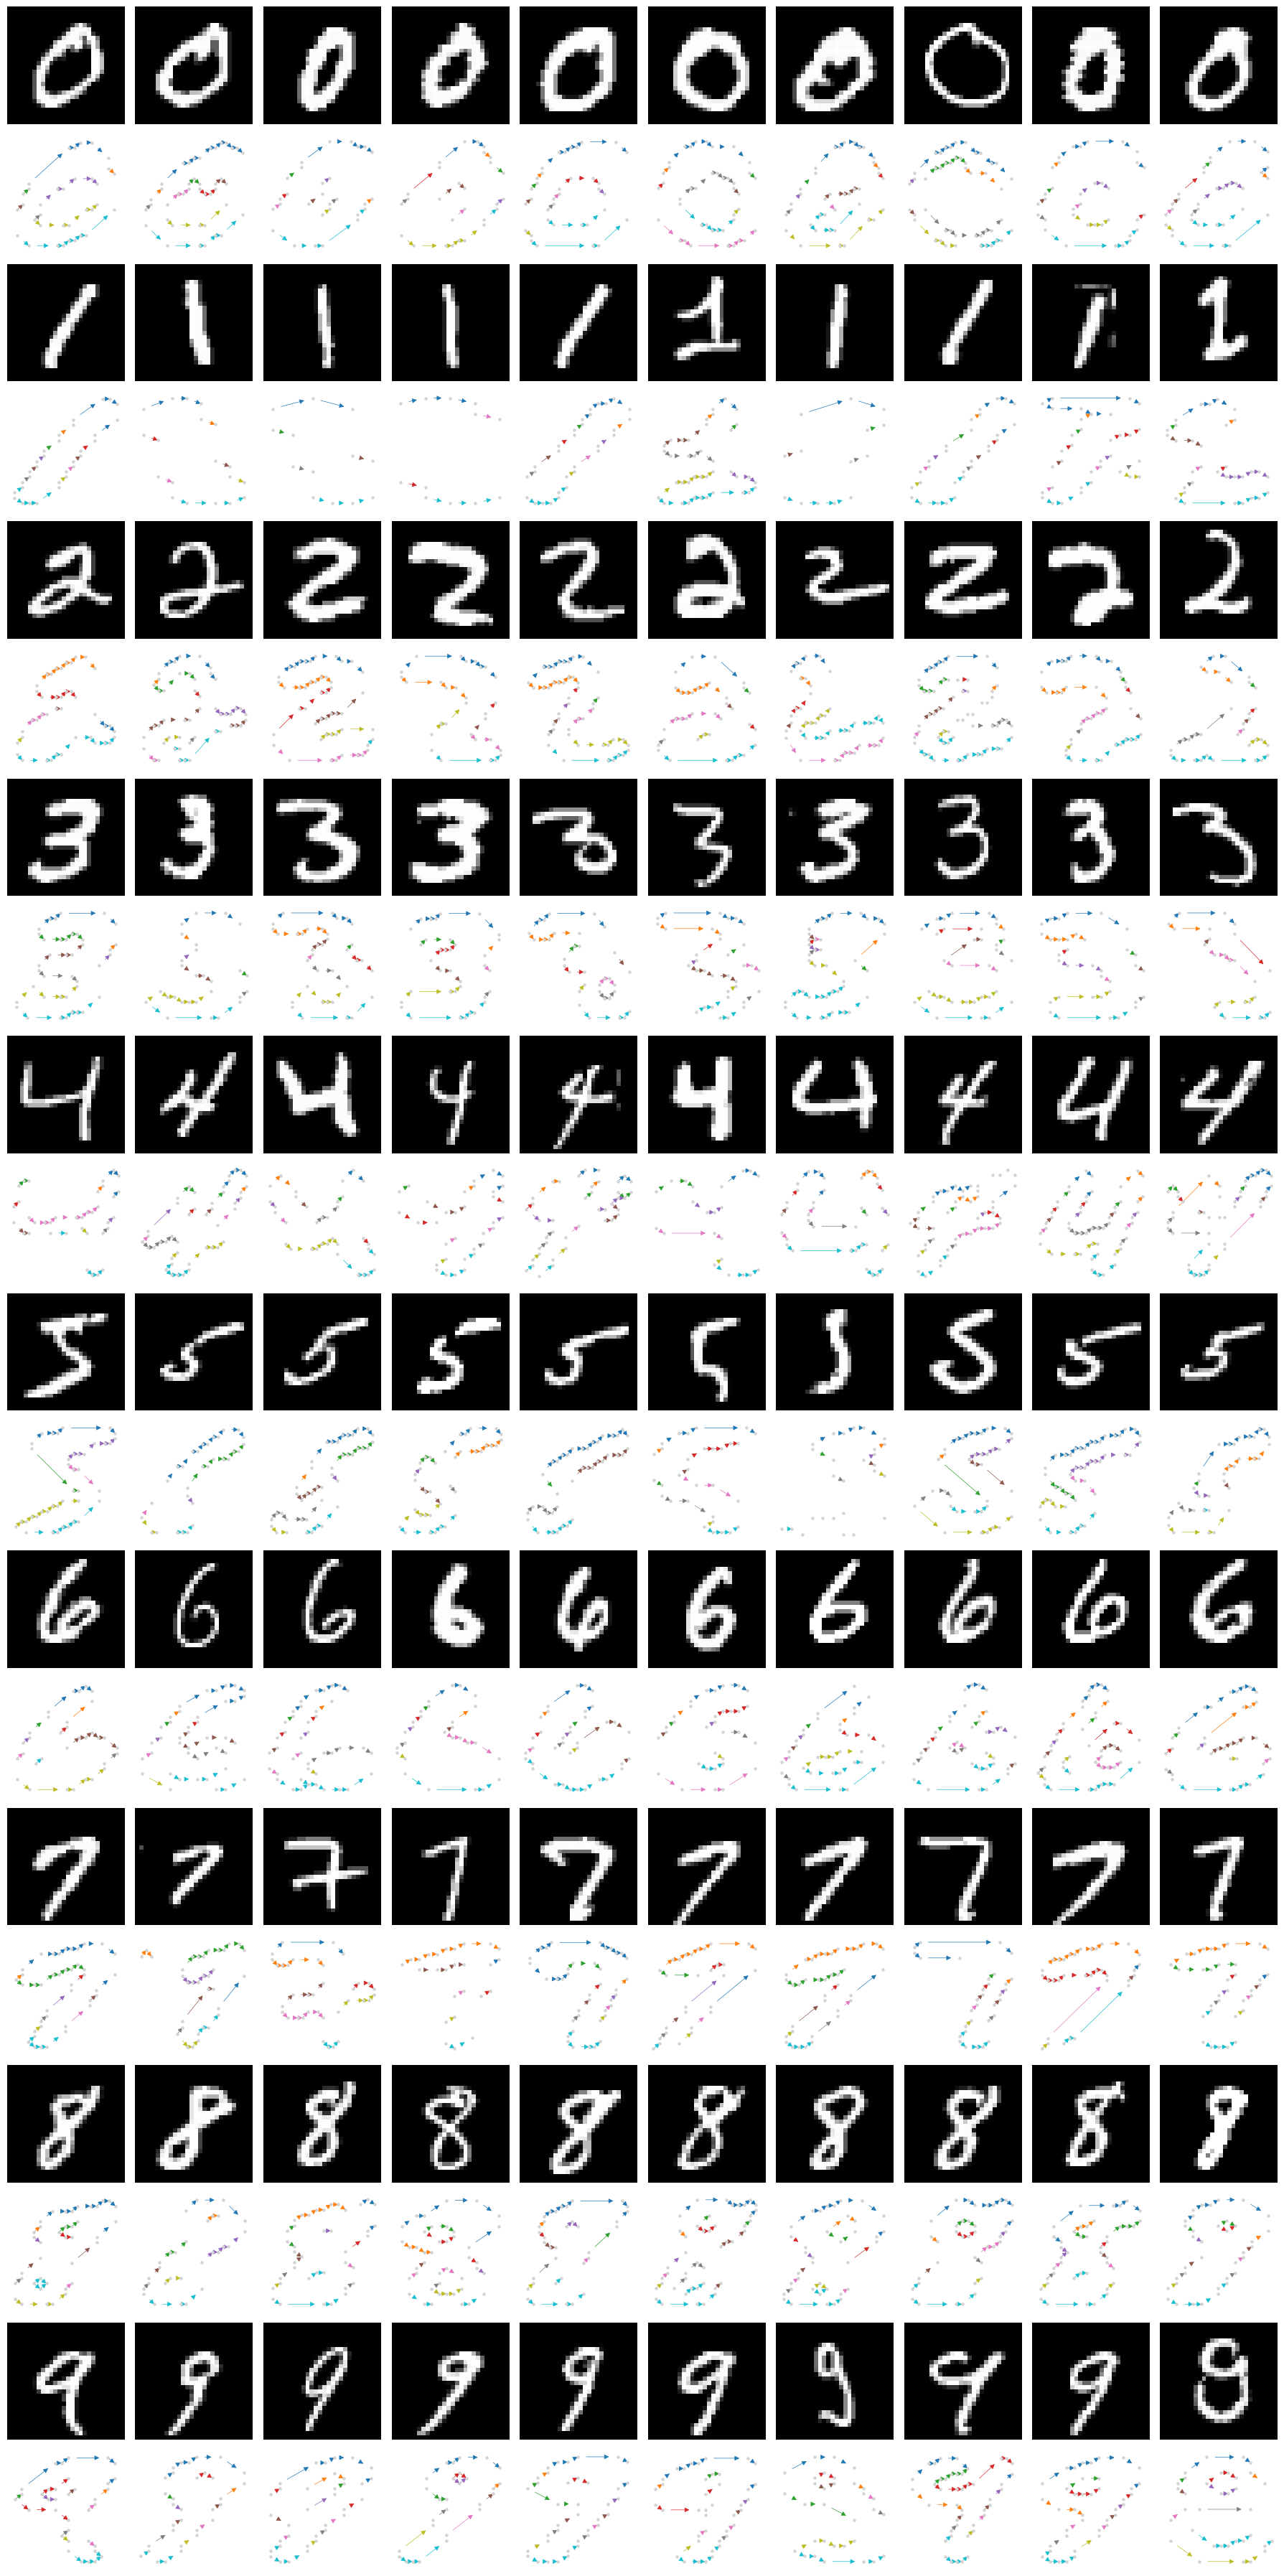

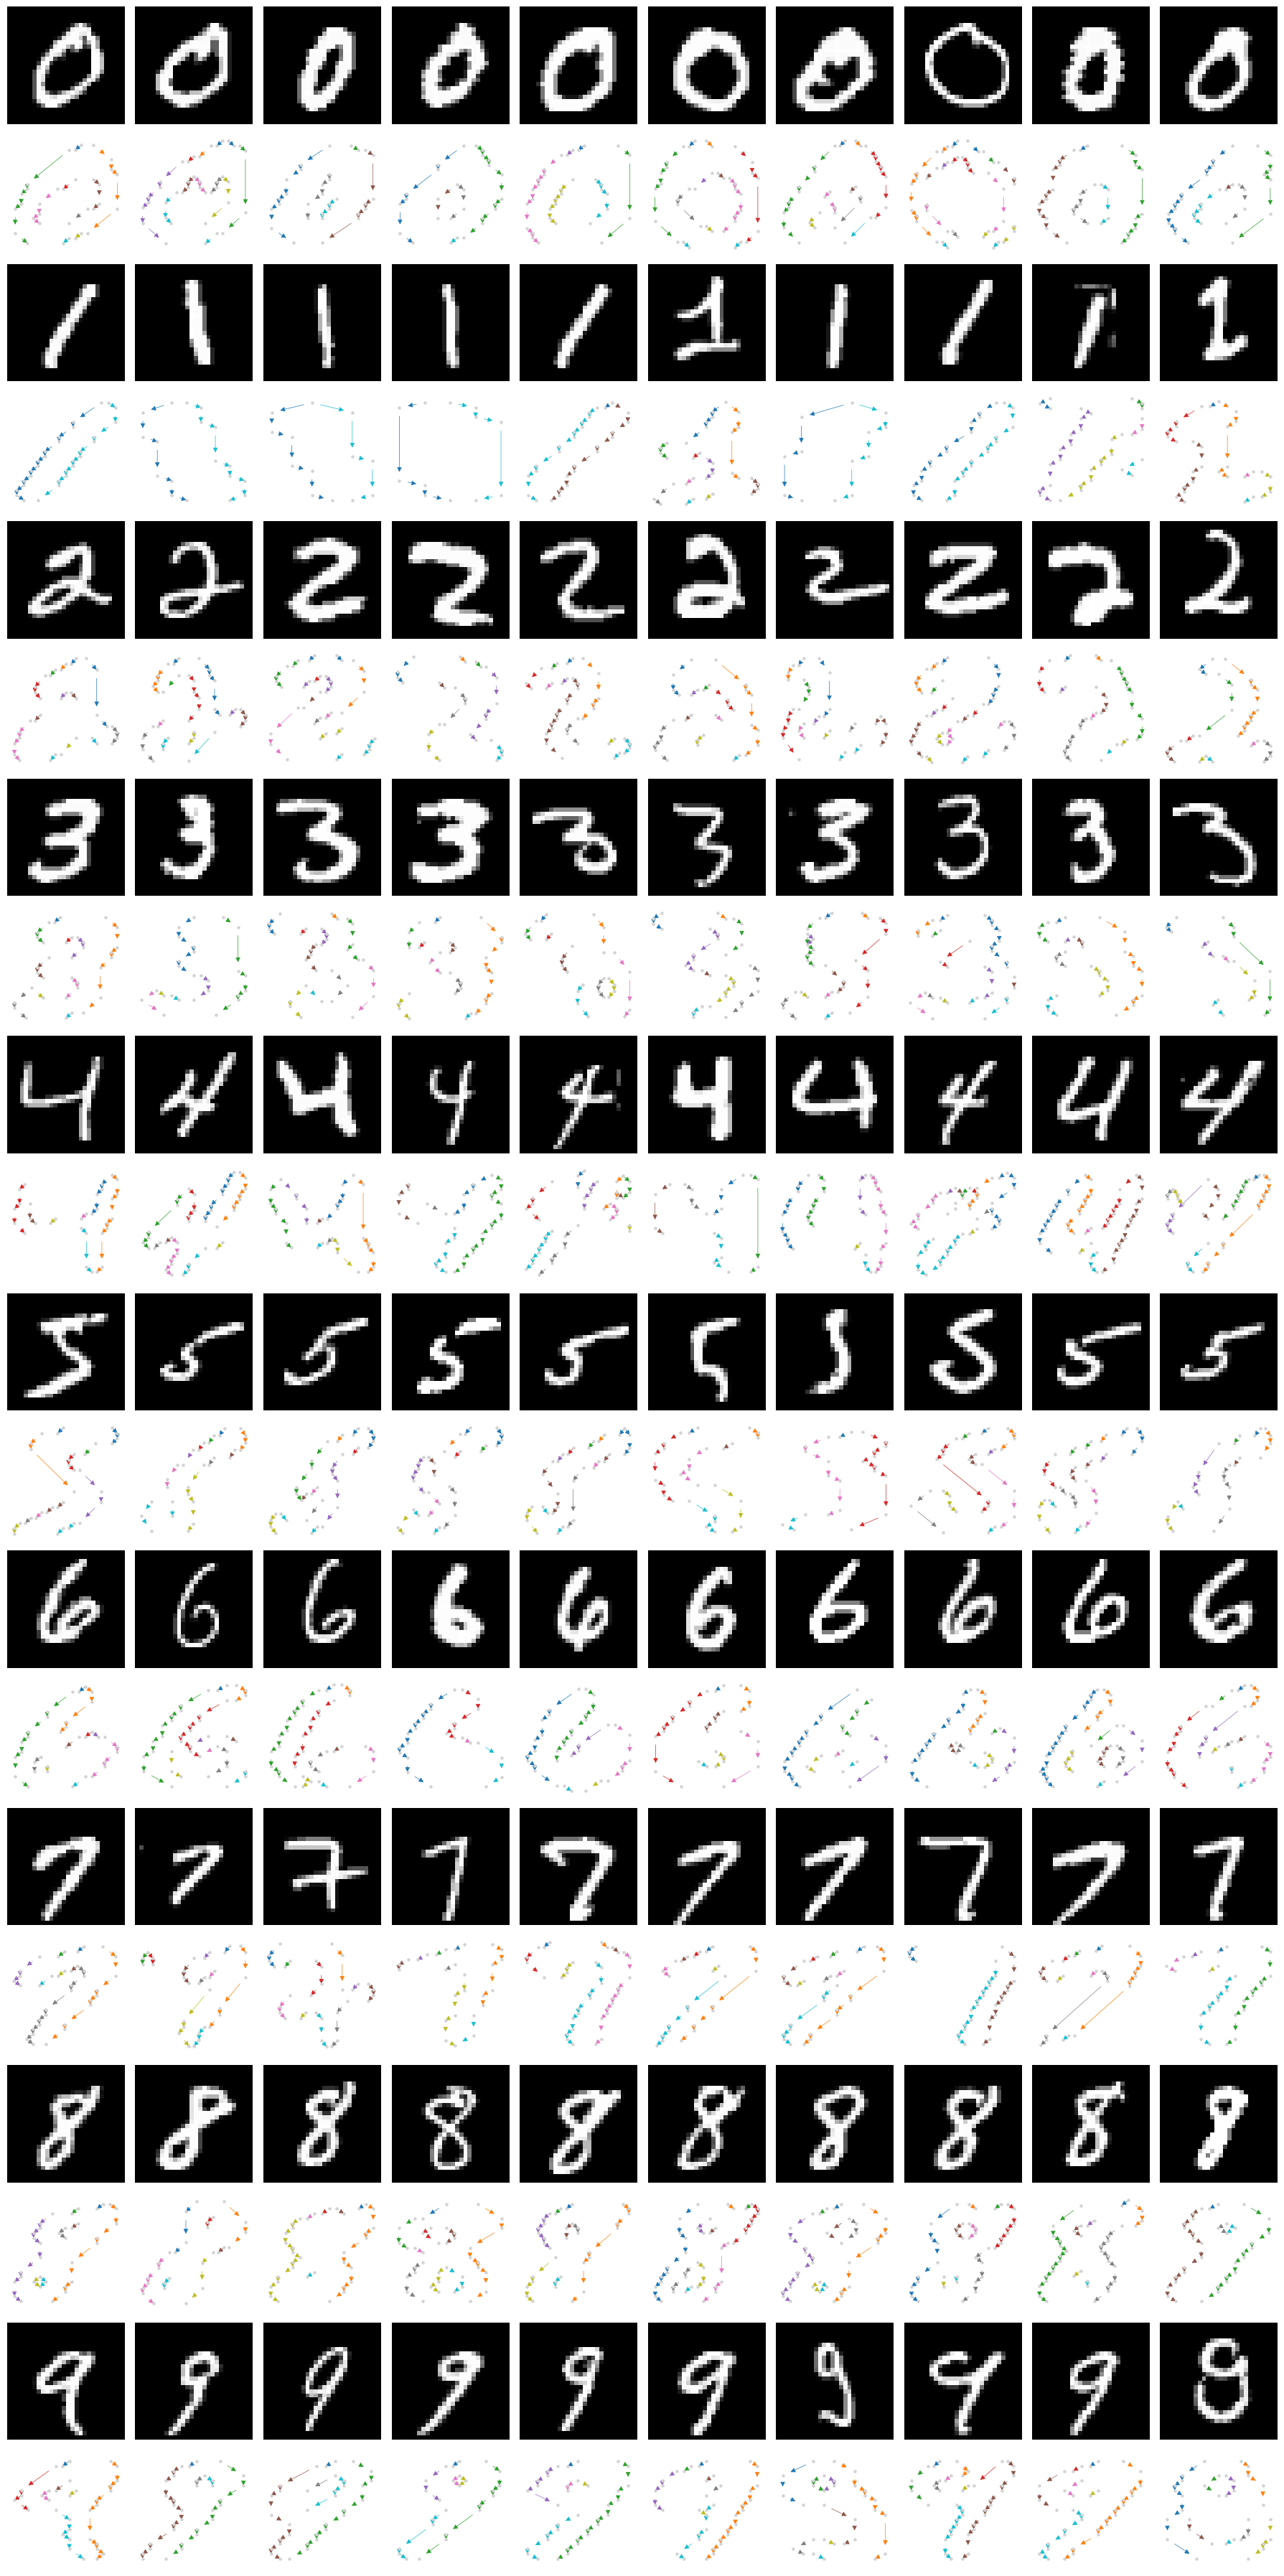

In [139]:
fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        merged_G = merge_similar_edges(G, angle_threshold=10)
        G_lr, _ = build_directed_graphs(merged_G)

        # Now extract directed paths from the merged graph
        merged_positions = nx.get_node_attributes(merged_G, 'pos')
        merged_paths = extract_directed_paths(G_lr)

        plot_graph_with_paths(G_lr, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        merged_G = merge_similar_edges(G, angle_threshold=10)
        _, G_td = build_directed_graphs(merged_G)

        # Now extract directed paths from the merged graph
        merged_positions = nx.get_node_attributes(merged_G, 'pos')
        merged_paths = extract_directed_paths(G_td)

        plot_graph_with_paths(G_td, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()

### Show for all digits, smoothing thereshold = $50.0$

/var/folders/13/crxfzs191916h3vs0r4spxt40000gn/T/ipykernel_80541/1267628222.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(paths))


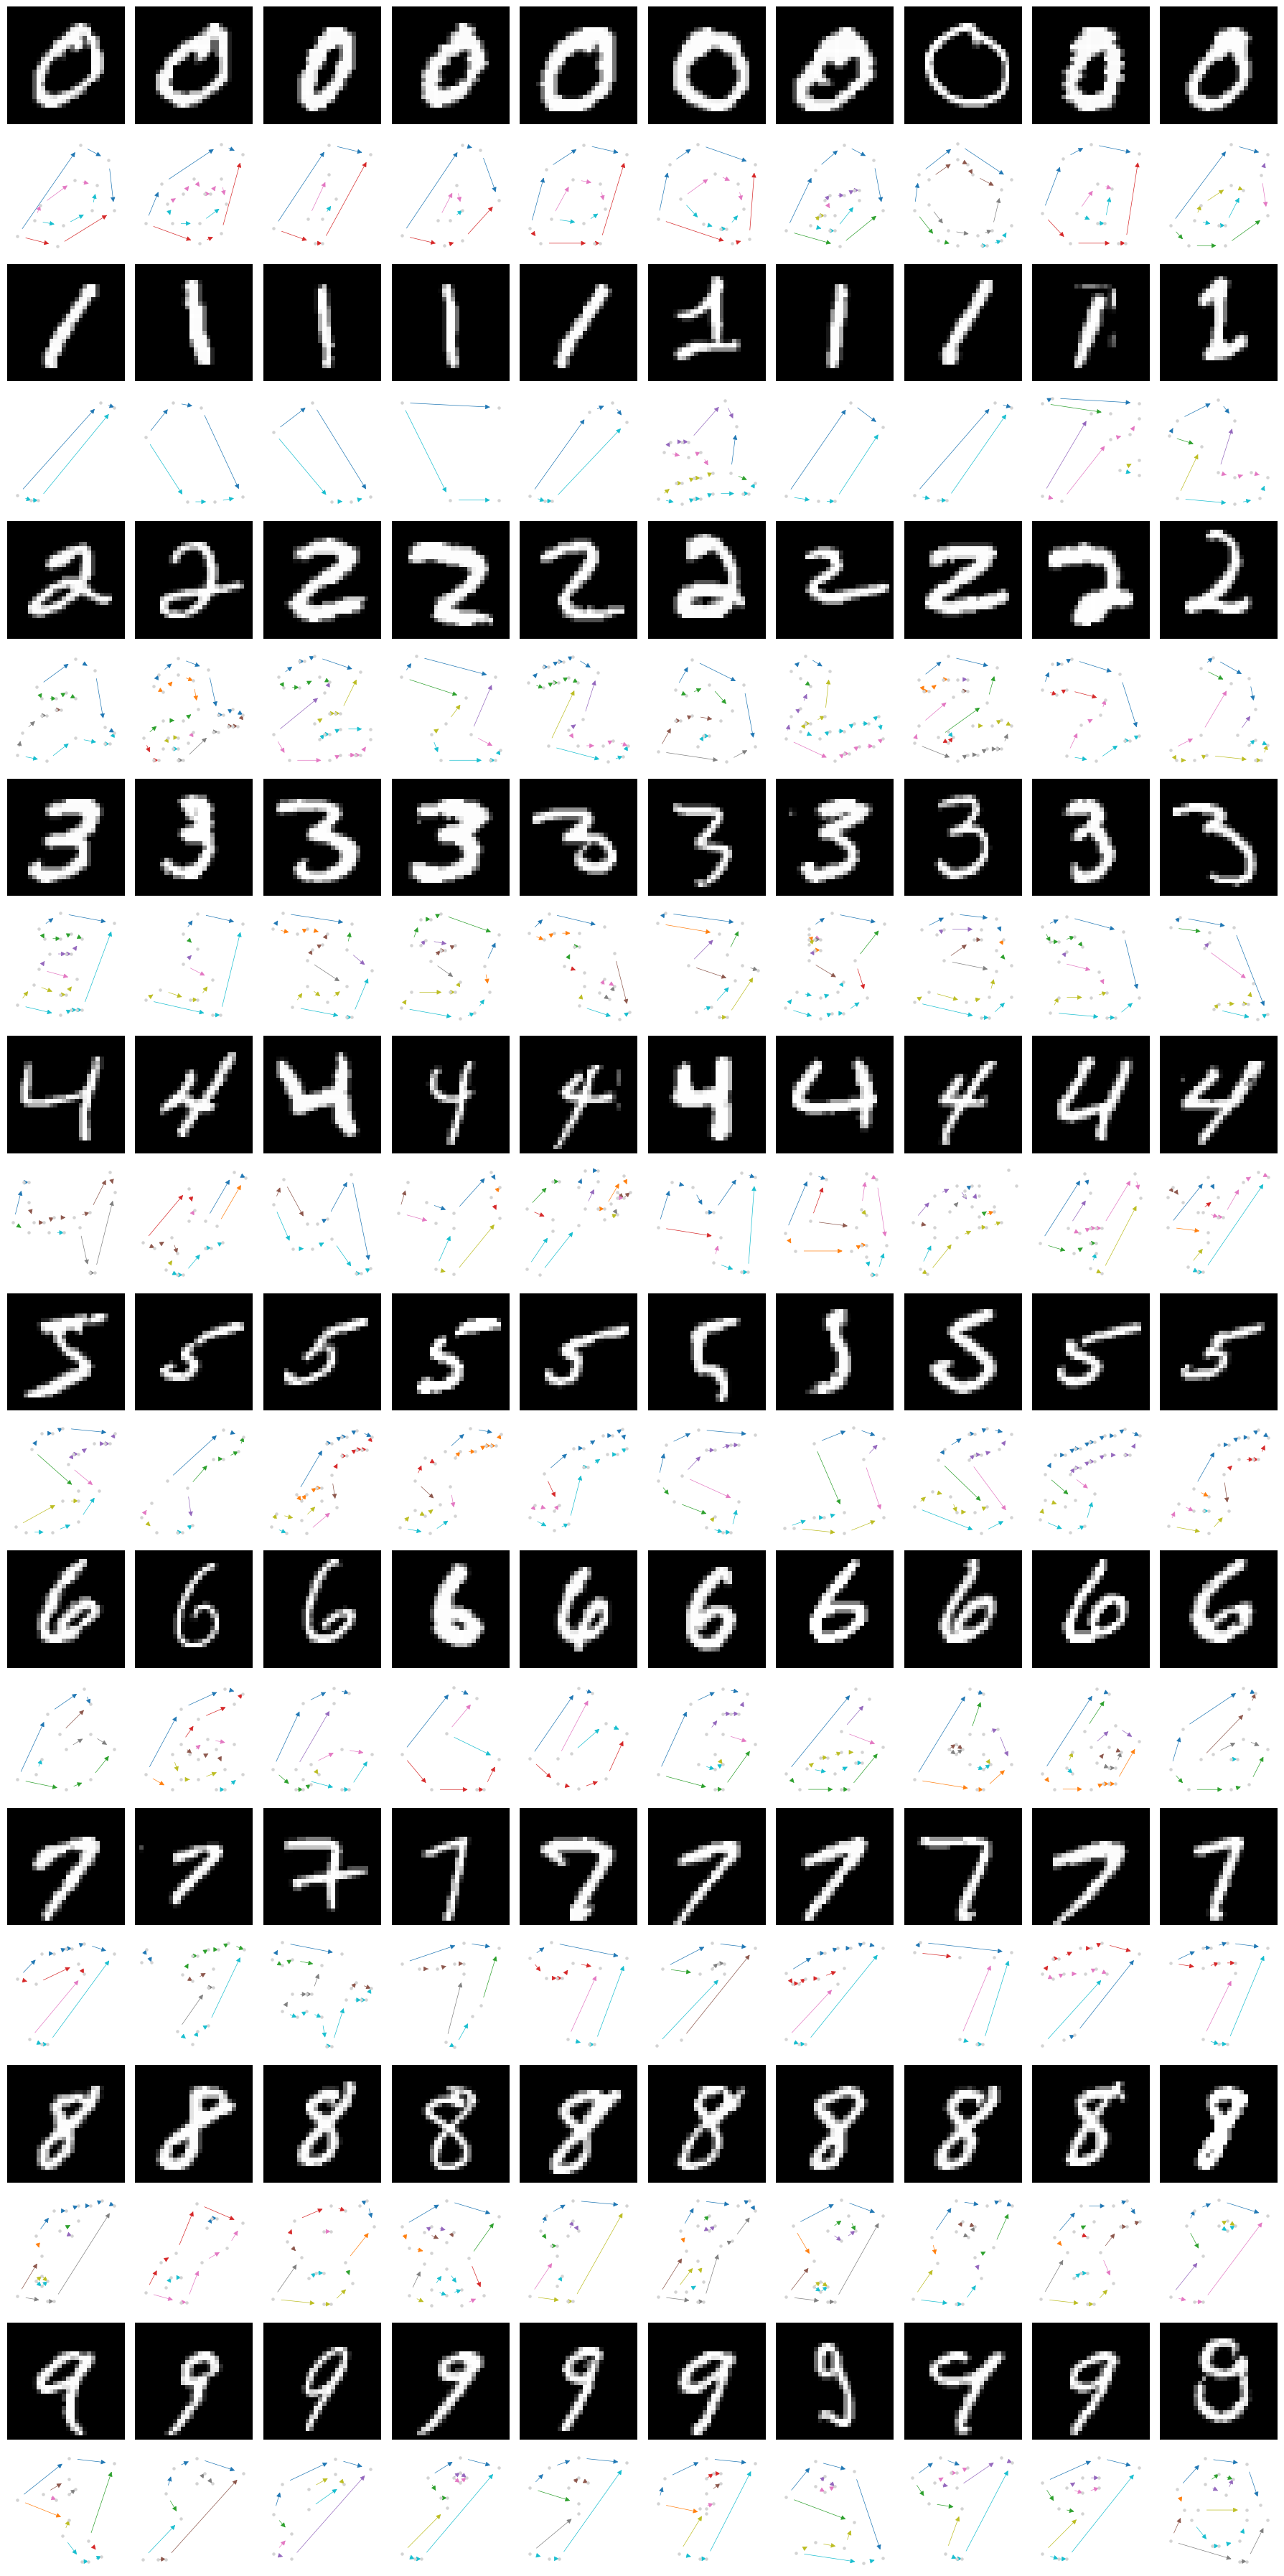

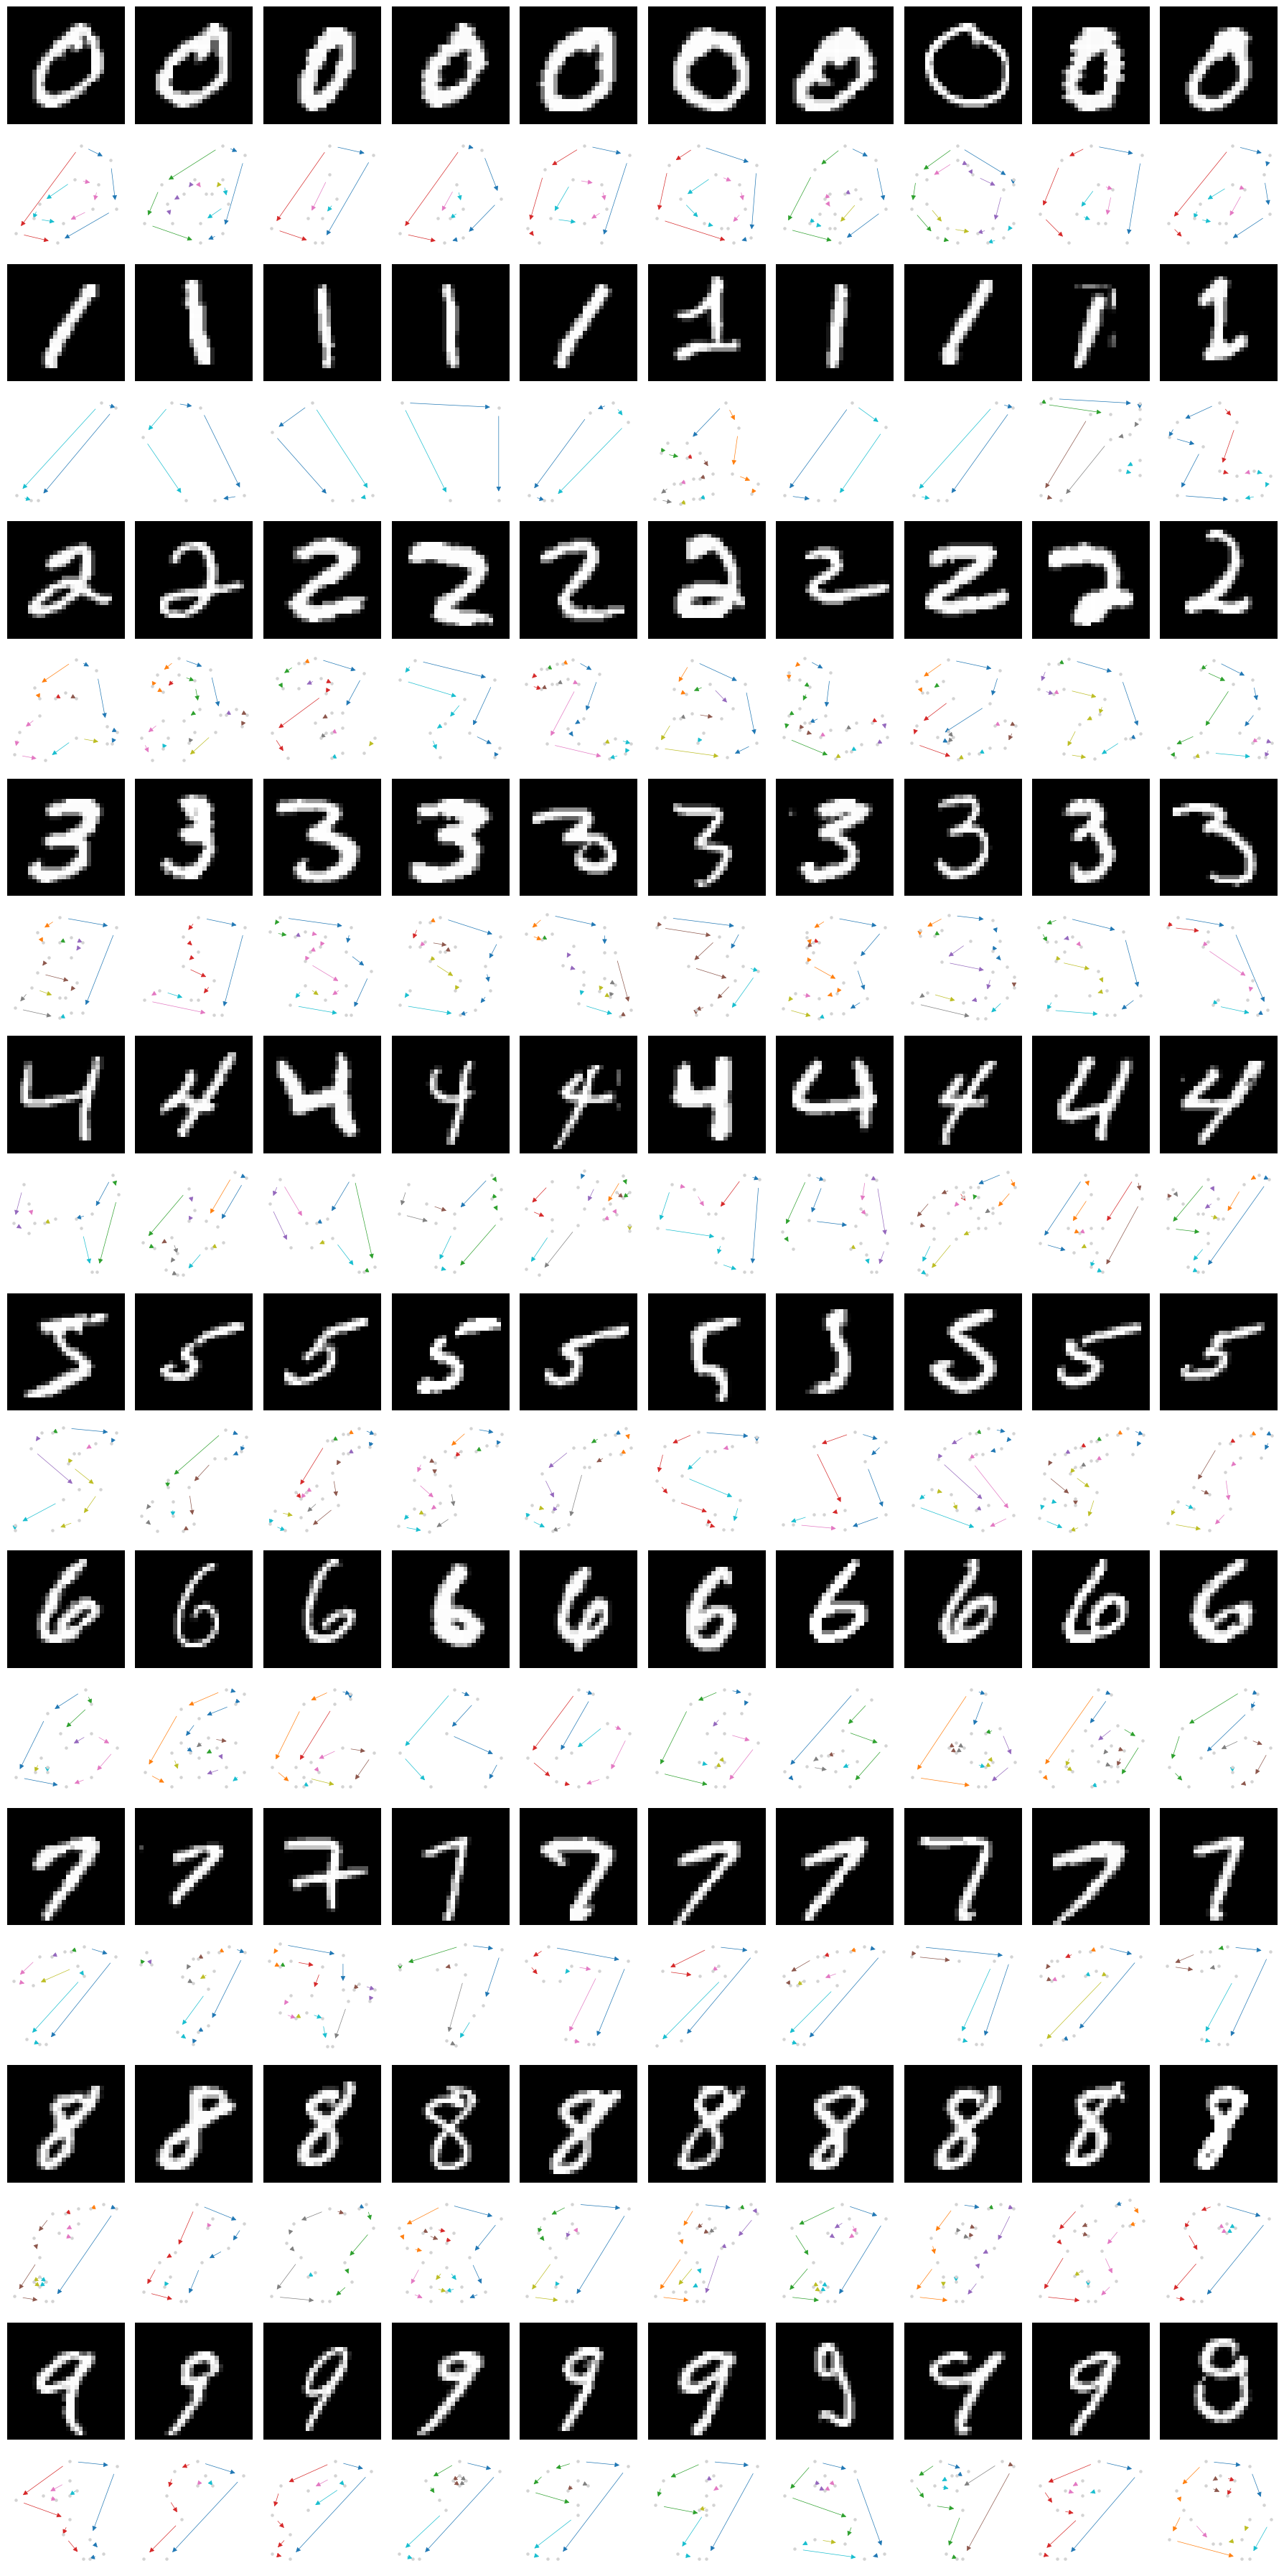

In [141]:
fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')
        
        G = mnist_to_graph(image)
        merged_G = merge_similar_edges(G, angle_threshold=50)
        G_lr, _ = build_directed_graphs(merged_G)

        # Now extract directed paths from the merged graph
        merged_positions = nx.get_node_attributes(merged_G, 'pos')
        merged_paths = extract_directed_paths(G_lr)

        plot_graph_with_paths(G_lr, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(20, 10, figsize=(18, 36))

for digit in range(10):
    images = x_train[y_train == digit][:10]
    for sample_idx, image in enumerate(images):
        ax_img = axes[2 * digit, sample_idx]
        ax_graph = axes[2 * digit + 1, sample_idx]

        ax_img.imshow(image, cmap='gray')
        ax_img.axis('off')

        G = mnist_to_graph(image)
        merged_G = merge_similar_edges(G, angle_threshold=50)
        _, G_td = build_directed_graphs(merged_G)

        # Now extract directed paths from the merged graph
        merged_positions = nx.get_node_attributes(merged_G, 'pos')
        merged_paths = extract_directed_paths(G_td)

        plot_graph_with_paths(G_td, merged_paths, merged_positions, ax_graph, "", node_size=5, verbose=False)
        ax_graph.axis('off')

plt.tight_layout()
plt.show()